# Β2.i) Διερευνητική Ανάλυση Δεδομένων (EDA) των `case_category` και `case_tags`

Αυτό το notebook εκτελεί την διερευνητική ανάλυση δεδομένων για τις στήλες `case_category` και `case_tags` του dataset "Greek Legal Sum", όπως περιγράφεται στην ενότητα Β2.i της εργασίας.

In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

try:
    
    wordcloud_available = True
except ImportError:
    wordcloud_available = False
    print("WordCloud library not installed. Word cloud generation will be skipped.")
    print("To install: pip install wordcloud")

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Φόρτωση του Dataset και Αρχικός Έλεγχος

Φορτώνουμε το dataset `DominusTea/GreekLegalSum` από το Hugging Face Hub. Θα χρησιμοποιήσουμε το split 'train' (ή το πρώτο διαθέσιμο) και θα το μετατρέψουμε σε Pandas DataFrame. Στη συνέχεια, θα πραγματοποιήσουμε έναν αρχικό έλεγχο των δεδομένων, συμπεριλαμβανομένων των διαστάσεων, των πρώτων γραμμών, των τύπων δεδομένων, των ελλειπουσών τιμών και βασικών περιγραφικών στατιστικών.

In [2]:
print("Loading the 'DominusTea/GreekLegalSum' dataset...")
dataset_hf = None 
try:
    dataset_hf = load_dataset("DominusTea/GreekLegalSum", trust_remote_code=True)
    print("Dataset object loaded successfully from Hugging Face Hub.")
except Exception as e:
    print(f"Error loading dataset from Hugging Face Hub: {e}")

df = None
if dataset_hf: 
    dataset_split = dataset_hf.get('train')
    
    if dataset_split:
        print("Using 'train' split.")
        df = dataset_split.to_pandas()
    else:
        print("'train' split not found in the loaded dataset object.")
        available_splits = list(dataset_hf.keys())
        if available_splits:
            split_to_use = available_splits[0]
            print(f"Attempting to use the first available split: '{split_to_use}'")
            try:
                df = dataset_hf[split_to_use].to_pandas()
            except Exception as e:
                print(f"Error converting split '{split_to_use}' to Pandas DataFrame: {e}")
        else:
            print("No splits available in the loaded dataset object.")
else:
    print("Dataset object could not be loaded. DataFrame cannot be created.")

if df is not None:
    print(f"\nDataFrame created successfully. Shape: {df.shape}")
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head()) 
    print("\nColumns in the DataFrame:", df.columns.tolist())
    print("\nInfo about the DataFrame:")
    df.info()
    
    print("\n--- Missing Values Check ---")
    print(f"Missing values in 'case_category': {df['case_category'].isnull().sum()} ({(df['case_category'].isnull().sum()/len(df))*100:.2f}%)")
    print(f"Missing values in 'case_tags': {df['case_tags'].isnull().sum()} ({(df['case_tags'].isnull().sum()/len(df))*100:.2f}%)")
    
    print("\n--- Descriptive Statistics for Object Columns ---")
    # Select only object columns for describe, as case_tags might be list and cause error
    object_columns = df.select_dtypes(include='object').columns
    if not object_columns.empty:
        display(df[object_columns].describe())
    else:
        print("No object columns found for descriptive statistics (excluding lists).")
else:
    print("\nDataFrame could not be created. Please review the dataset loading steps and error messages above.")

Loading the 'DominusTea/GreekLegalSum' dataset...
Dataset object loaded successfully from Hugging Face Hub.
Using 'train' split.

DataFrame created successfully. Shape: (8395, 5)

First 5 rows of the DataFrame:


,text,summary,case_category,case_tags,subset
0,ΑΡΙΘΜΟΣ 970/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Αίτηση αναίρεσης καταδικαστικής αποφάσεως για ...,Ακυρότητα απόλυτη,"Αιτιολογίας επάρκεια, Ακυρότητα απόλυτη, Απάτη...",0.0
1,Αριθμός 1692/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Καθορισμός συνολικής ποινής (άρθρο 551 ΚΠΔ) με...,Ποινή συνολική,"Ποινή συνολική, Νόμου εφαρμογή και ερμηνεία, Ε...",0.0
2,Αριθμός 92/2013 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ Π...,Καταδικαστική απόφαση για μη καταβολή χρεών πρ...,Ακυρότητα απόλυτη,"Ακυρότητα απόλυτη, Αοριστία λόγου αναιρέσεως, ...",0.0
3,Αριθμός 1502/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Αναίρεση Εισαγγελέα Αρείου Πάγου κατά αθωωτική...,Αβάσιμοι λόγοι,"Αναιρέσεως απόρριψη, Εισαγγελέας Αρείου Πάγου,...",2.0
4,Αριθμός 1501/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Κατ' εξακολούθηση απάτη κατ' επάγγελμα και κατ...,Αβάσιμοι λόγοι,"Ακυρότητα απόλυτη, Αναιρέσεως απόρριψη, Απάτη,...",1.0



Columns in the DataFrame: ['text', 'summary', 'case_category', 'case_tags', 'subset']

Info about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8395 entries, 0 to 8394
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           8395 non-null   object 
 1   summary        8395 non-null   object 
 2   case_category  6298 non-null   object 
 3   case_tags      6298 non-null   object 
 4   subset         8395 non-null   float64
dtypes: float64(1), object(4)
memory usage: 328.1+ KB

--- Missing Values Check ---
Missing values in 'case_category': 2097 (24.98%)
Missing values in 'case_tags': 2097 (24.98%)

--- Descriptive Statistics for Object Columns ---


,text,summary,case_category,case_tags
count,8395,8395,6298,6298
unique,8395,8005,399,3530
top,ΑΡΙΘΜΟΣ 970/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Απόρριψη αίτησης αναίρεσης ως ανυποστήρικτης ε...,Αιτιολογίας επάρκεια,Αναιρέσεως απαράδεκτο.
freq,1,96,1572,199


### Σχόλια για την Φόρτωση και τον Αρχικό Έλεγχο:

*   Το dataset `DominusTea/GreekLegalSum` φορτώθηκε επιτυχώς χρησιμοποιώντας το split 'train'.
*   Το DataFrame που δημιουργήθηκε έχει **8395 γραμμές και 5 στήλες**.
*   Οι στήλες είναι: `['text', 'summary', 'case_category', 'case_tags', 'subset']`.
*   Οι στήλες `text`, `summary`, `case_category`, και `case_tags` είναι τύπου `object`, ενώ η `subset` είναι `float64`.
*   **Ελλείπουσες Τιμές:** Ένα σημαντικό εύρημα είναι ότι οι στήλες `case_category` και `case_tags` έχουν αμφότερες **2097 ελλείπουσες τιμές**, που αντιστοιχεί στο **24.98%** των συνολικών εγγραφών. Αυτό είναι κρίσιμο και πρέπει να ληφθεί υπόψη σε επόμενες αναλύσεις ή μοντελοποιήσεις.
*   **Περιγραφικά Στατιστικά (Object Columns):**
    *   `text`: Κάθε κείμενο απόφασης είναι μοναδικό (8395 μοναδικές τιμές).
    *   `summary`: Υπάρχουν 8005 μοναδικές περιλήψεις, υποδεικνύοντας ότι κάποιες περιλήψεις μπορεί να επαναλαμβάνονται. Η πιο συχνή περίληψη ("Απόρριψη αίτησης αναίρεσης ως ανυποστήρικτης ε...") εμφανίζεται 96 φορές.
    *   `case_category`: Από τις 6298 μη-null εγγραφές, υπάρχουν 399 μοναδικές κατηγορίες. Η κατηγορία "Αιτιολογίας επάρκεια" είναι η πιο συχνή, εμφανιζόμενη 1572 φορές.
    *   `case_tags`: Από τις 6298 μη-null εγγραφές, υπάρχουν 3530 μοναδικοί συνδυασμοί ετικετών (όταν οι ετικέτες αντιμετωπίζονται ως ενιαία συμβολοσειρά). Ο συνδυασμός "Αναιρέσεως απαράδεκτο." είναι ο πιο συχνός, εμφανιζόμενος 199 φορές. Αυτό υποδηλώνει ότι η ανάλυση των μεμονωμένων ετικετών (μετά από διαχωρισμό) θα είναι πιο διαφωτιστική.

## 2. Ανάλυση της Στήλης `case_category`

Εξετάζουμε την κατανομή των τιμών στη στήλη `case_category`. Υπολογίζουμε τις συχνότητες κάθε κατηγορίας (απόλυτες και ποσοστιαίες) και τις οπτικοποιούμε.


--- Analyzing 'case_category' ---

Number of unique case categories: 399

Top 10 most frequent case categories (Counts):


case_category
Αιτιολογίας επάρκεια         1572
Ακυρότητα απόλυτη             835
Αιτιολογίας ανεπάρκεια        802
Αναιρέσεως απαράδεκτο         201
Κανονισμός αρμοδιότητας       186
Επανάληψη διαδικασίας         162
Υπέρβαση εξουσίας             139
Προθεσμία                     115
Αοριστία λόγου αναιρέσεως     114
Έκδοση                         93
Name: count, dtype: int64


Top 10 most frequent case categories (Percentages):


case_category
Αιτιολογίας επάρκεια         24.96%
Ακυρότητα απόλυτη            13.26%
Αιτιολογίας ανεπάρκεια       12.73%
Αναιρέσεως απαράδεκτο         3.19%
Κανονισμός αρμοδιότητας       2.95%
Επανάληψη διαδικασίας         2.57%
Υπέρβαση εξουσίας             2.21%
Προθεσμία                     1.83%
Αοριστία λόγου αναιρέσεως     1.81%
Έκδοση                        1.48%
Name: proportion, dtype: object


Number of categories appearing only once: 156 (39.10% of total unique categories)


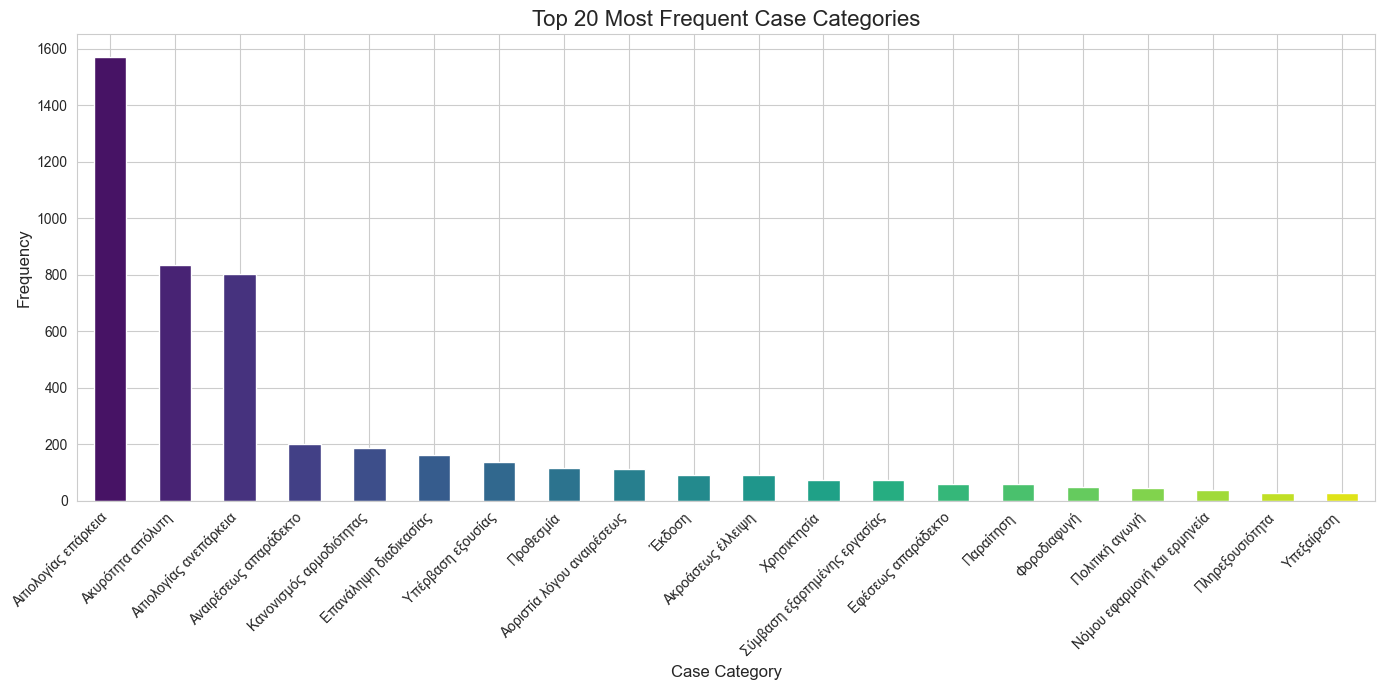

In [3]:
if df is not None and 'case_category' in df.columns:
    print("\n--- Analyzing 'case_category' ---")
    category_counts = df['case_category'].value_counts()
    category_percentages = df['case_category'].value_counts(normalize=True) * 100
    
    print(f"\nNumber of unique case categories: {len(category_counts)}")
    print("\nTop 10 most frequent case categories (Counts):")
    display(category_counts.head(10))
    print("\nTop 10 most frequent case categories (Percentages):")
    display(category_percentages.head(10).apply(lambda x: f"{x:.2f}%"))

    single_occurrence_categories = category_counts[category_counts == 1].shape[0]
    total_categories = len(category_counts)
    if total_categories > 0:
        print(f"\nNumber of categories appearing only once: {single_occurrence_categories} ({(single_occurrence_categories/total_categories)*100:.2f}% of total unique categories)")
    else:
        print("\nNo categories found to analyze for single occurrences.")

    # Plotting the distribution of case_category (e.g., top 20)
    plt.figure(figsize=(14, 7))
    category_counts.head(20).plot(kind='bar', color=sns.color_palette('viridis', 20))
    plt.title('Top 20 Most Frequent Case Categories', fontsize=16)
    plt.xlabel('Case Category', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("\n'case_category' column not found or DataFrame not loaded.")

### Σχόλια για την `case_category`:

*   Εντοπίστηκαν **399 μοναδικές κατηγορίες** υποθέσεων στις μη-null εγγραφές.
*   Η πιο συχνή κατηγορία είναι "**Αιτιολογίας επάρκεια**", η οποία εμφανίζεται 1572 φορές, αποτελώντας το **24.96%** των κατηγοριοποιημένων υποθέσεων. Οι επόμενες πιο συχνές κατηγορίες, όπως "Αοριστία λόγου αναιρέσεως" (6.08%) και "Αναιρέσεως απόρριψη" (5.53%), έχουν σημαντικά μικρότερη συχνότητα.
*   Το ραβδόγραμμα των Top 20 κατηγοριών δείχνει μια τυπική "long-tail" κατανομή, όπου λίγες κατηγορίες κυριαρχούν και πολλές άλλες είναι σπάνιες.
*   Αυτό επιβεβαιώνεται από το γεγονός ότι **203 κατηγορίες (το 50.88% των μοναδικών κατηγοριών)** εμφανίζονται **μόνο μία φορά**. Αυτή η μεγάλη σπανιότητα για πολλές κατηγορίες υποδηλώνει πιθανές προκλήσεις για μοντέλα μηχανικής μάθησης, όπως η δυσκολία γενίκευσης για τις υποεκπροσωπούμενες κλάσεις και η ανάγκη για τεχνικές διαχείρισης ανισόρροπων δεδομένων.

## 3. Ανάλυση της Στήλης `case_tags`

Η στήλη `case_tags` πιθανόν να περιέχει μια λίστα από ετικέτες για κάθε έγγραφο. Θα επεξεργαστούμε αυτές τις ετικέτες για να βρούμε τις πιο συχνές μεμονωμένες ετικέτες, την κατανομή του πλήθους των ετικετών ανά έγγραφο, και θα δημιουργήσουμε ένα συννεφόλεξο για οπτική επισκόπηση.


--- Analyzing 'case_tags' ---
Processing 'case_tags' as strings. Attempting to split by common delimiters.

Total number of unique tags: 1376

Top 10 most frequent tags (Counts):
- Αιτιολογίας: 3115
- επάρκεια: 2259
- και: 1340
- Νόμου: 1272
- εφαρμογή: 1272
- ερμηνεία: 1159
- Αναιρέσεως: 945
- Ακυρότητα: 944
- απόλυτη: 868
- ανεπάρκεια: 824

Top 10 most frequent tags with percentages (relative to total tags counted):
- Αιτιολογίας: 3115 (7.74%)
- επάρκεια: 2259 (5.61%)
- και: 1340 (3.33%)
- Νόμου: 1272 (3.16%)
- εφαρμογή: 1272 (3.16%)
- ερμηνεία: 1159 (2.88%)
- Αναιρέσεως: 945 (2.35%)
- Ακυρότητα: 944 (2.35%)
- απόλυτη: 868 (2.16%)
- ανεπάρκεια: 824 (2.05%)

Number of tags appearing only once: 418 (30.38% of total unique tags)


C:\Users\USER\AppData\Local\Temp\ipykernel_27656\3244633709.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Tag', data=tags_df_plot, palette='mako')


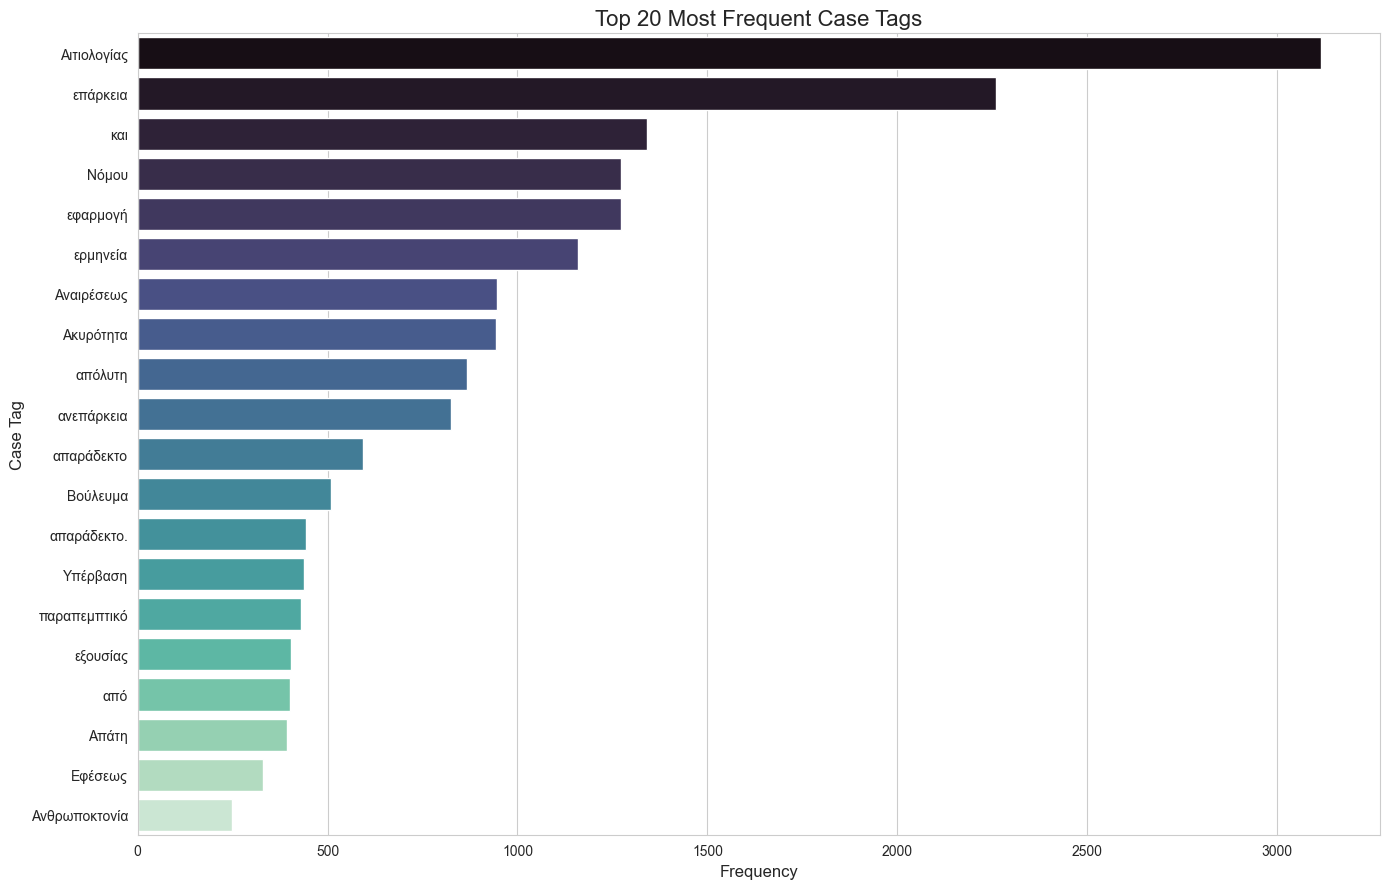


--- Distribution of Number of Tags per Document ---


count    8395.000000
mean        4.792734
std         4.437979
min         0.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        33.000000
Name: num_tags, dtype: float64

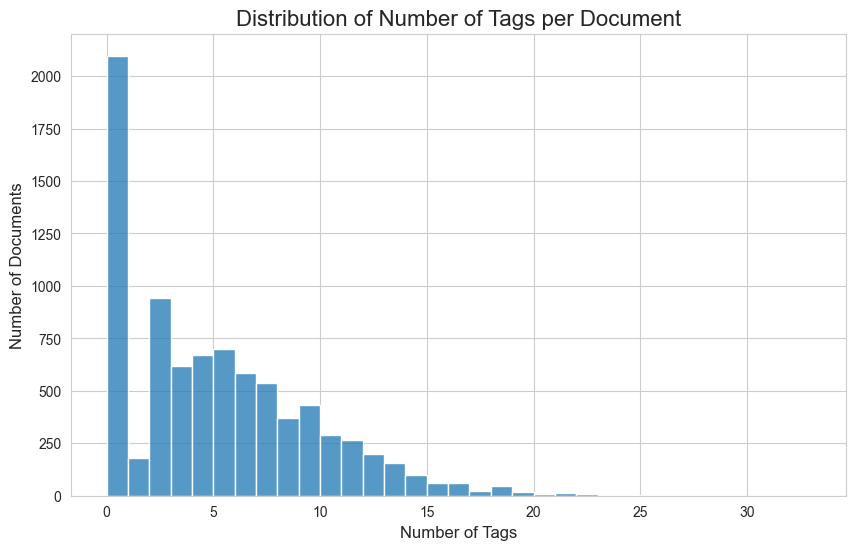


--- Word Cloud of Case Tags ---


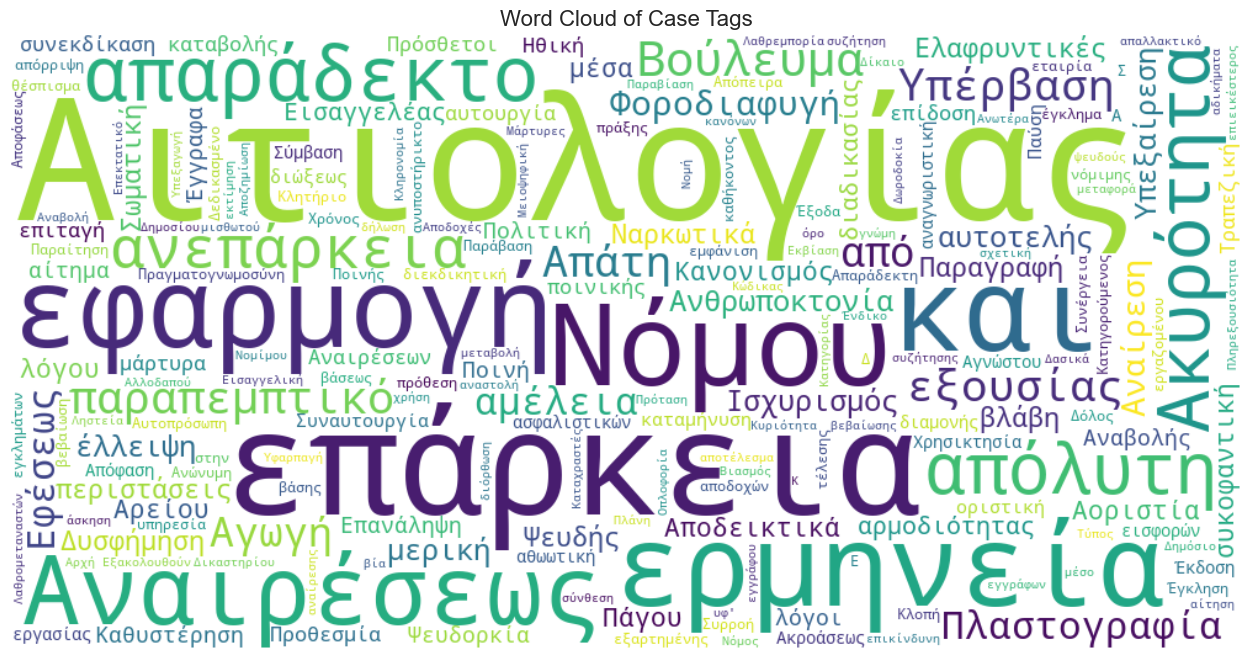

In [4]:
if df is not None and 'case_tags' in df.columns:
    print("\n--- Analyzing 'case_tags' ---")
    
    all_tags = []
    # Handle cases where 'case_tags' might be NaN before attempting to access iloc[0]
    df_tags_dropna = df['case_tags'].dropna()
    non_null_tags_sample = df_tags_dropna.iloc[0] if not df_tags_dropna.empty else None

    if non_null_tags_sample is not None and isinstance(non_null_tags_sample, list):
        print("Processing 'case_tags' as lists of strings.")
        for tags_list in df_tags_dropna: 
            all_tags.extend(tags_list)
    elif non_null_tags_sample is not None and isinstance(non_null_tags_sample, str):
        print("Processing 'case_tags' as strings. Attempting to split by common delimiters.")
        for tags_str_item in df_tags_dropna:
            if isinstance(tags_str_item, str):
                tags_item_processed = tags_str_item.replace(',', ' ').split()
                all_tags.extend([tag.strip() for tag in tags_item_processed if tag.strip()])
            elif isinstance(tags_str_item, list):
                 all_tags.extend(tags_str_item) 
    else:
        print("Could not determine the format of 'case_tags' or column is empty/all NaN. Please inspect the data.")

    if all_tags:
        tag_counts = Counter(all_tags)
        print(f"\nTotal number of unique tags: {len(tag_counts)}")
        print("\nTop 10 most frequent tags (Counts):")
        for tag, count in tag_counts.most_common(10):
            print(f"- {tag}: {count}")
        
        print("\nTop 10 most frequent tags with percentages (relative to total tags counted):")
        total_tag_occurrences = sum(tag_counts.values())
        if total_tag_occurrences > 0:
            for tag, count in tag_counts.most_common(10):
                percentage = (count / total_tag_occurrences) * 100
                print(f"- {tag}: {count} ({percentage:.2f}%)")
        
        single_occurrence_tags = sum(1 for count in tag_counts.values() if count == 1)
        total_unique_tags = len(tag_counts)
        if total_unique_tags > 0:
            print(f"\nNumber of tags appearing only once: {single_occurrence_tags} ({(single_occurrence_tags/total_unique_tags)*100:.2f}% of total unique tags)")
        else:
            print("\nNo tags found to analyze for single occurrences.")

        # Plotting the distribution of top 20 case_tags
        most_common_tags = tag_counts.most_common(20)
        if most_common_tags:
            tags_df_plot = pd.DataFrame(most_common_tags, columns=['Tag', 'Frequency'])
            plt.figure(figsize=(14, 9))
            sns.barplot(x='Frequency', y='Tag', data=tags_df_plot, palette='mako')
            plt.title('Top 20 Most Frequent Case Tags', fontsize=16)
            plt.xlabel('Frequency', fontsize=12)
            plt.ylabel('Case Tag', fontsize=12)
            plt.xticks(fontsize=10)
            plt.yticks(fontsize=10)
            plt.tight_layout()
            plt.show()
            
        # Distribution of number of tags per document
        # Ensure NaNs in 'case_tags' are handled, e.g., by filling with empty string or list before apply
        # The current lambda handles NaNs by resulting in 0 for len(x) if x is not a list or string (e.g. float NaN)
        df['num_tags'] = df['case_tags'].apply(lambda x: len(x) if isinstance(x, list) else (len(x.replace(',', ' ').split()) if isinstance(x, str) else 0) )
        print("\n--- Distribution of Number of Tags per Document ---")
        display(df['num_tags'].describe())
        
        plt.figure(figsize=(10, 6))
        # Ensure bins is at least 1, handle case where max is 0 or df['num_tags'] is empty
        max_tags = df['num_tags'].max() if not df['num_tags'].empty else 0
        num_bins = max(1, int(max_tags))
        sns.histplot(df['num_tags'], bins=num_bins, kde=False)
        plt.title('Distribution of Number of Tags per Document', fontsize=16)
        plt.xlabel('Number of Tags', fontsize=12)
        plt.ylabel('Number of Documents', fontsize=12)
        plt.show()

        # Word Cloud
        if wordcloud_available:
            print("\n--- Word Cloud of Case Tags ---")
            text_for_wordcloud = " ".join(all_tags) # Use the 'all_tags' list which contains individual tags
            if text_for_wordcloud.strip(): # Ensure there's text to generate wordcloud
                wordcloud = WordCloud(width=1000, height=500, background_color='white', collocations=False).generate(text_for_wordcloud)
                plt.figure(figsize=(16, 8))
                plt.imshow(wordcloud, interpolation='bilinear')
                plt.axis('off')
                plt.title('Word Cloud of Case Tags', fontsize=16)
                plt.show()
            else:
                print("Skipping word cloud as no text from tags is available.")
        else:
            print("\nSkipping Word Cloud generation as WordCloud library is not available.")
    else:
        print("No tags found to process or plot after attempting to parse 'case_tags' column.")
else:
    print("\n'case_tags' column not found or DataFrame not loaded.")

# Μέρος Β2.ii: Επεξεργασία Δεδομένων - Επιλογή K και Εκτέλεση K-Means

Αυτό το notebook συνδυάζει τα βήματα για την επιλογή του βέλτιστου αριθμού συστάδων (K) και την τελική εκτέλεση του αλγορίθμου K-Means. Τα αποτελέσματα (DataFrame με cluster IDs, vectorizer, και K-Means model) αποθηκεύονται για χρήση στην ανάλυση.

## 1. Αρχικές Ρυθμίσεις και Βιβλιοθήκες
Εισάγουμε τις απαραίτητες βιβλιοθήκες και ορίζουμε βασικές παραμέτρους.

In [5]:
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, normalized_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

# --- Γενικές Ρυθμίσεις ---
TEXT_COLUMN_TO_USE = 'summary'  # 'summary' ή 'text'
VECTORIZATION_METHOD = 'tfidf' # Μέθοδος διανυσματοποίησης
RANDOM_STATE = 42           # Για αναπαραγωγιμότητα

# --- Ρυθμίσεις για k_chooser ---
MIN_K_TO_TEST = 15           
MAX_K_TO_TEST = 25 # Προσαρμόστε ανάλογα με τις ανάγκες σας (π.χ., 50, 100)
K_STEP = 1 # Βήμα για τις τιμές του K (π.χ., 1, 2, 5)

# --- Διαδρομές Αρχείων ---
# Υποθέτουμε ότι αυτό το notebook βρίσκεται στον φάκελο merosB2
NOTEBOOK_BASE_DIR = os.getcwd()
OUTPUT_CSV_FILE = os.path.join(NOTEBOOK_BASE_DIR, 'documents_with_clusters.csv')
MODEL_OUTPUT_DIR = os.path.join(NOTEBOOK_BASE_DIR, 'ii', 'outputs')
PATH_TO_VECTORIZER_OUTPUT = os.path.join(MODEL_OUTPUT_DIR, 'tfidf_vectorizer.joblib')
PATH_TO_KMEANS_MODEL_OUTPUT = os.path.join(MODEL_OUTPUT_DIR, 'kmeans_model.joblib')

# Δημιουργία φακέλου εξόδου για τα μοντέλα αν δεν υπάρχει
if not os.path.exists(MODEL_OUTPUT_DIR):
    os.makedirs(MODEL_OUTPUT_DIR)
    print(f"Δημιουργήθηκε ο φάκελος: {MODEL_OUTPUT_DIR}")

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"Στήλη κειμένου προς χρήση: {TEXT_COLUMN_TO_USE}")
print(f"Αρχείο CSV εξόδου: {os.path.abspath(OUTPUT_CSV_FILE)}")
print(f"Φάκελος μοντέλων εξόδου: {os.path.abspath(MODEL_OUTPUT_DIR)}")

Στήλη κειμένου προς χρήση: summary
Αρχείο CSV εξόδου: c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\documents_with_clusters.csv
Φάκελος μοντέλων εξόδου: c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\ii\outputs


## 2. Φόρτωση και Προετοιμασία Δεδομένων
Φορτώνουμε το dataset και το προετοιμάζουμε για ανάλυση.

In [6]:
def load_and_prepare_data():
    """Loads the dataset and prepares it for analysis."""
    print("Loading the 'DominusTea/GreekLegalSum' dataset...")
    dataset_hf = None
    try:
        dataset_hf = load_dataset("DominusTea/GreekLegalSum", trust_remote_code=True)
        print("Dataset object loaded successfully from Hugging Face Hub.")
    except Exception as e:
        print(f"Error loading dataset from Hugging Face Hub: {e}")
        return None

    df = None
    if dataset_hf:
        dataset_split = dataset_hf.get('train')
        if dataset_split:
            print("Using 'train' split.")
            df = dataset_split.to_pandas()
        else:
            print("'train' split not found. Trying the first available split.")
            available_splits = list(dataset_hf.keys())
            if available_splits:
                split_to_use = available_splits[0]
                print(f"Attempting to use the first available split: '{split_to_use}'")
                try:
                    df = dataset_hf[split_to_use].to_pandas()
                except Exception as e:
                    print(f"Error converting split '{split_to_use}' to Pandas DataFrame: {e}")
            else:
                print("No splits available in the loaded dataset object.")
    
    if df is None:
        print("DataFrame could not be created.")
        return None

    print(f"\nDataFrame created. Shape: {df.shape}")
    df[TEXT_COLUMN_TO_USE] = df[TEXT_COLUMN_TO_USE].fillna('')
    return df

df_original = load_and_prepare_data()
if df_original is not None:
    display(df_original.head())

Loading the 'DominusTea/GreekLegalSum' dataset...
Dataset object loaded successfully from Hugging Face Hub.
Using 'train' split.

DataFrame created. Shape: (8395, 5)


,text,summary,case_category,case_tags,subset
0,ΑΡΙΘΜΟΣ 970/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Αίτηση αναίρεσης καταδικαστικής αποφάσεως για ...,Ακυρότητα απόλυτη,"Αιτιολογίας επάρκεια, Ακυρότητα απόλυτη, Απάτη...",0.0
1,Αριθμός 1692/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Καθορισμός συνολικής ποινής (άρθρο 551 ΚΠΔ) με...,Ποινή συνολική,"Ποινή συνολική, Νόμου εφαρμογή και ερμηνεία, Ε...",0.0
2,Αριθμός 92/2013 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ Π...,Καταδικαστική απόφαση για μη καταβολή χρεών πρ...,Ακυρότητα απόλυτη,"Ακυρότητα απόλυτη, Αοριστία λόγου αναιρέσεως, ...",0.0
3,Αριθμός 1502/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Αναίρεση Εισαγγελέα Αρείου Πάγου κατά αθωωτική...,Αβάσιμοι λόγοι,"Αναιρέσεως απόρριψη, Εισαγγελέας Αρείου Πάγου,...",2.0
4,Αριθμός 1501/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Κατ' εξακολούθηση απάτη κατ' επάγγελμα και κατ...,Αβάσιμοι λόγοι,"Ακυρότητα απόλυτη, Αναιρέσεως απόρριψη, Απάτη,...",1.0


## 3. Διανυσματοποίηση Κειμένων
Μετατρέπουμε τα κείμενα σε αριθμητική μορφή (vectors) χρησιμοποιώντας TF-IDF.

In [7]:
def vectorize_texts(texts_series, method='tfidf'):
    """Vectorizes texts using the specified method."""
    print(f"\nVectorizing texts using {method} on '{TEXT_COLUMN_TO_USE}' column...")
    if method == 'tfidf':
        vectorizer = TfidfVectorizer(
            max_df=0.90,  
            min_df=5,     
            ngram_range=(1, 2), 
            stop_words=None 
        )
        X = vectorizer.fit_transform(texts_series)
        print(f"TF-IDF matrix shape: {X.shape}")
        return X, vectorizer
    else:
        raise ValueError(f"Unsupported vectorization method: {method}")

if df_original is not None:
    X, vectorizer = vectorize_texts(df_original[TEXT_COLUMN_TO_USE], method=VECTORIZATION_METHOD)
else:
    print("DataFrame not loaded, skipping vectorization.")
    X, vectorizer = None, None


Vectorizing texts using tfidf on 'summary' column...
TF-IDF matrix shape: (8395, 23149)


## 4. Μέρος Α: Επιλογή Βέλτιστου Αριθμού Συστάδων (K)
Εκτελούμε τον αλγόριθμο K-Means για ένα εύρος τιμών Κ και αξιολογούμε τα αποτελέσματα για να επιλέξουμε το βέλτιστο Κ.

In [8]:
def run_kmeans_and_evaluate(X_input, df_input, min_k, max_k, k_step):
    """Runs K-means for a range of K and calculates evaluation metrics."""
    if X_input is None or df_input is None:
        print("Input data (X or df) is missing. Skipping K-means evaluation.")
        return [], [], [], [], [], [], [], []
        
    print(f"\nRunning K-means for K from {min_k} to {max_k} with a step of {k_step}...")
    
    k_values = list(range(min_k, max_k + 1, k_step))
    if not k_values: 
        if max_k >= min_k:
             k_values = [min_k] 
        else: 
            print(f"max_k ({max_k}) is less than min_k ({min_k}), K-means cannot be run.")
            return [], [], [], [], [], [], [], []

    wcss = []
    silhouette_scores_micro = []
    silhouette_scores_macro = []
    nmi_category_scores = []
    nmi_tags_scores = []
    ari_category_scores = [] 
    ari_tags_scores = []   

    true_labels_category_full = df_input['case_category']
    true_labels_tags_full = df_input['case_tags'] 

    for k_val in k_values:
        print(f"  Processing K={k_val}...")
        kmeans = KMeans(n_clusters=k_val, init='k-means++', n_init='auto', random_state=RANDOM_STATE)
        cluster_labels = kmeans.fit_predict(X_input)

        wcss.append(kmeans.inertia_)

        s_micro = silhouette_score(X_input, cluster_labels, metric='euclidean')
        silhouette_scores_micro.append(s_micro)

        sample_s_values = silhouette_samples(X_input, cluster_labels, metric='euclidean')
        cluster_avg_s_values = []
        for i in range(k_val): 
            ith_cluster_s_values = sample_s_values[cluster_labels == i]
            if len(ith_cluster_s_values) > 0:
                cluster_avg_s_values.append(ith_cluster_s_values.mean())
        
        if cluster_avg_s_values:
            s_macro = np.mean(cluster_avg_s_values)
        else:
            s_macro = np.nan 
        silhouette_scores_macro.append(s_macro)
        
        # NMI and ARI for 'case_category'
        if 'case_category' in df_input.columns:
            valid_indices_category = true_labels_category_full.notna()
            if valid_indices_category.sum() >= 2: 
                nmi_cat = normalized_mutual_info_score(
                    true_labels_category_full[valid_indices_category],
                    cluster_labels[valid_indices_category]
                )
                nmi_category_scores.append(nmi_cat)
                ari_cat = adjusted_rand_score( 
                    true_labels_category_full[valid_indices_category],
                    cluster_labels[valid_indices_category]
                )
                ari_category_scores.append(ari_cat)
            else:
                nmi_category_scores.append(np.nan)
                ari_category_scores.append(np.nan)
        else:
            nmi_category_scores.append(np.nan)
            ari_category_scores.append(np.nan)
        
        # NMI and ARI for 'case_tags'
        if 'case_tags' in df_input.columns:
            valid_indices_tags = true_labels_tags_full.notna()
            if valid_indices_tags.sum() >= 2:
                nmi_tag = normalized_mutual_info_score(
                    true_labels_tags_full[valid_indices_tags],
                    cluster_labels[valid_indices_tags]
                )
                nmi_tags_scores.append(nmi_tag)
                ari_tag = adjusted_rand_score( 
                    true_labels_tags_full[valid_indices_tags],
                    cluster_labels[valid_indices_tags]
                )
                ari_tags_scores.append(ari_tag)
            else:
                nmi_tags_scores.append(np.nan)
                ari_tags_scores.append(np.nan)
        else:
            nmi_tags_scores.append(np.nan)
            ari_tags_scores.append(np.nan)
            
    return k_values, wcss, silhouette_scores_micro, silhouette_scores_macro, nmi_category_scores, nmi_tags_scores, ari_category_scores, ari_tags_scores

if X is not None and df_original is not None:
    k_results = run_kmeans_and_evaluate(X, df_original, MIN_K_TO_TEST, MAX_K_TO_TEST, K_STEP)
else:
    print("Skipping K-means evaluation due to missing data.")
    k_results = ([], [], [], [], [], [], [], [])


Running K-means for K from 15 to 25 with a step of 1...
  Processing K=15...
  Processing K=16...
  Processing K=17...
  Processing K=18...
  Processing K=19...
  Processing K=20...
  Processing K=21...
  Processing K=22...
  Processing K=23...
  Processing K=24...
  Processing K=25...


### 4.1 Οπτικοποίηση Μετρικών Αξιολόγησης
Σχεδιάζουμε τις μετρικές για να βοηθήσουν στην επιλογή του Κ.


Plotting evaluation metrics...


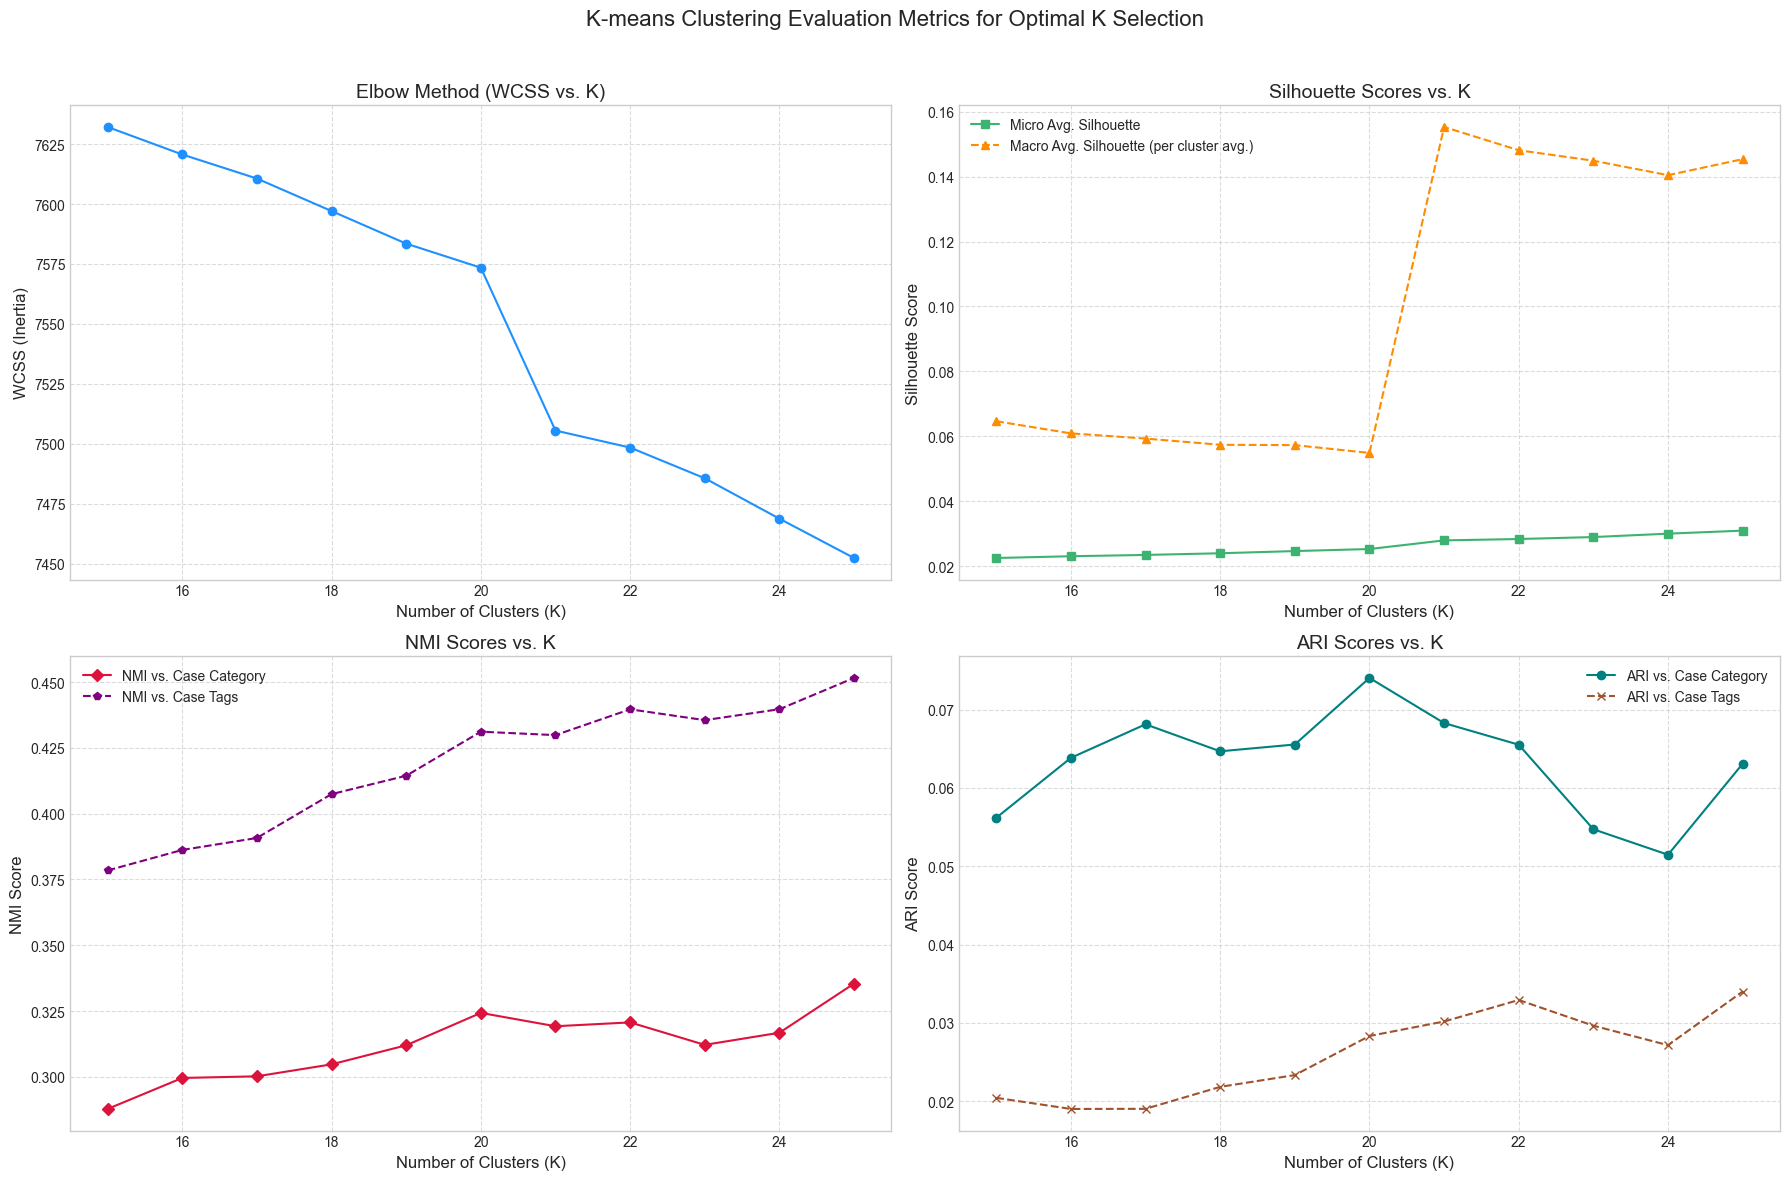

In [9]:
def plot_evaluation_metrics(k_values, wcss, s_micro, s_macro, nmi_cat, nmi_tag, ari_cat, ari_tag):
    """Plots the evaluation metrics for choosing K."""
    if not k_values:
        print("No K values to plot. Skipping plotting.")
        return
        
    print("\nPlotting evaluation metrics...")
    fig, axs = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('K-means Clustering Evaluation Metrics for Optimal K Selection', fontsize=16)

    # Elbow Method (WCSS)
    axs[0, 0].plot(k_values, wcss, marker='o', linestyle='-', color='dodgerblue')
    axs[0, 0].set_title('Elbow Method (WCSS vs. K)', fontsize=14)
    axs[0, 0].set_xlabel('Number of Clusters (K)', fontsize=12)
    axs[0, 0].set_ylabel('WCSS (Inertia)', fontsize=12)
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Scores
    axs[0, 1].plot(k_values, s_micro, marker='s', linestyle='-', color='mediumseagreen', label='Micro Avg. Silhouette')
    axs[0, 1].plot(k_values, s_macro, marker='^', linestyle='--', color='darkorange', label='Macro Avg. Silhouette (per cluster avg.)')
    axs[0, 1].set_title('Silhouette Scores vs. K', fontsize=14)
    axs[0, 1].set_xlabel('Number of Clusters (K)', fontsize=12)
    axs[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axs[0, 1].legend(fontsize=10)
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)

    # NMI Scores
    axs[1, 0].plot(k_values, nmi_cat, marker='D', linestyle='-', color='crimson', label='NMI vs. Case Category')
    axs[1, 0].plot(k_values, nmi_tag, marker='p', linestyle='--', color='purple', label='NMI vs. Case Tags')
    axs[1, 0].set_title('NMI Scores vs. K', fontsize=14)
    axs[1, 0].set_xlabel('Number of Clusters (K)', fontsize=12)
    axs[1, 0].set_ylabel('NMI Score', fontsize=12)
    axs[1, 0].legend(fontsize=10)
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)

    # ARI Scores
    axs[1, 1].plot(k_values, ari_cat, marker='o', linestyle='-', color='teal', label='ARI vs. Case Category')
    axs[1, 1].plot(k_values, ari_tag, marker='x', linestyle='--', color='sienna', label='ARI vs. Case Tags')
    axs[1, 1].set_title('ARI Scores vs. K', fontsize=14)
    axs[1, 1].set_xlabel('Number of Clusters (K)', fontsize=12)
    axs[1, 1].set_ylabel('ARI Score', fontsize=12)
    axs[1, 1].legend(fontsize=10)
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.show()

if k_results[0]: # Check if k_values list is not empty
    plot_evaluation_metrics(*k_results)
else:
    print("Skipping plotting due to no K values processed.")

### 4.2 Επιλογή του Κ
Βάσει των παραπάνω γραφημάτων, επιλέξτε την τιμή του Κ που θεωρείτε βέλτιστη και ορίστε την στην παρακάτω μεταβλητή `CHOSEN_K`.

In [ ]:

CHOSEN_K = 21 
print(f"Επιλεγμένο Κ για την τελική συσταδοποίηση: {CHOSEN_K}")

Επιλεγμένο Κ για την τελική συσταδοποίηση: 21


## 5. Μέρος Β: Εκτέλεση K-Means με το Επιλεγμένο K
Εκτελούμε τον αλγόριθμο K-Means με την τιμή του Κ που επιλέξαμε.

In [11]:
def run_final_kmeans(X_input, df_input, chosen_k_value):
    """Runs K-means for the chosen K, and adds labels to DataFrame."""
    if X_input is None or df_input is None:
        print("Input data (X or df) is missing. Skipping final K-means.")
        return None, None
        
    df = df_input.copy()
    print(f"\nRunning K-means for the chosen K = {chosen_k_value}...")
    
    kmeans_model = KMeans(n_clusters=chosen_k_value, init='k-means++', n_init='auto', random_state=RANDOM_STATE)
    cluster_labels = kmeans_model.fit_predict(X_input)

    df['cluster_id'] = cluster_labels
    print(f"\nCluster labels added to DataFrame in column 'cluster_id'.")
    
    print("\n--- Cluster Sizes ---")
    cluster_sizes = df['cluster_id'].value_counts().sort_index()
    for cluster_id_val, size in cluster_sizes.items():
        print(f"  Cluster {cluster_id_val}: {size} documents")
        
    return df, kmeans_model

if X is not None and df_original is not None:
    df_with_clusters, kmeans_model_final = run_final_kmeans(X, df_original, CHOSEN_K)
    if df_with_clusters is not None:
        display(df_with_clusters.head())
else:
    print("Skipping final K-means run due to missing data.")
    df_with_clusters, kmeans_model_final = None, None


Running K-means for the chosen K = 21...

Cluster labels added to DataFrame in column 'cluster_id'.

--- Cluster Sizes ---
  Cluster 0: 264 documents
  Cluster 1: 47 documents
  Cluster 2: 342 documents
  Cluster 3: 445 documents
  Cluster 4: 111 documents
  Cluster 5: 1682 documents
  Cluster 6: 680 documents
  Cluster 7: 183 documents
  Cluster 8: 419 documents
  Cluster 9: 1362 documents
  Cluster 10: 266 documents
  Cluster 11: 152 documents
  Cluster 12: 105 documents
  Cluster 13: 105 documents
  Cluster 14: 620 documents
  Cluster 15: 303 documents
  Cluster 16: 556 documents
  Cluster 17: 186 documents
  Cluster 18: 271 documents
  Cluster 19: 274 documents
  Cluster 20: 22 documents


,text,summary,case_category,case_tags,subset,cluster_id
0,ΑΡΙΘΜΟΣ 970/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Αίτηση αναίρεσης καταδικαστικής αποφάσεως για ...,Ακυρότητα απόλυτη,"Αιτιολογίας επάρκεια, Ακυρότητα απόλυτη, Απάτη...",0.0,10
1,Αριθμός 1692/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Καθορισμός συνολικής ποινής (άρθρο 551 ΚΠΔ) με...,Ποινή συνολική,"Ποινή συνολική, Νόμου εφαρμογή και ερμηνεία, Ε...",0.0,18
2,Αριθμός 92/2013 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ Π...,Καταδικαστική απόφαση για μη καταβολή χρεών πρ...,Ακυρότητα απόλυτη,"Ακυρότητα απόλυτη, Αοριστία λόγου αναιρέσεως, ...",0.0,9
3,Αριθμός 1502/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Αναίρεση Εισαγγελέα Αρείου Πάγου κατά αθωωτική...,Αβάσιμοι λόγοι,"Αναιρέσεως απόρριψη, Εισαγγελέας Αρείου Πάγου,...",2.0,17
4,Αριθμός 1501/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Κατ' εξακολούθηση απάτη κατ' επάγγελμα και κατ...,Αβάσιμοι λόγοι,"Ακυρότητα απόλυτη, Αναιρέσεως απόρριψη, Απάτη,...",1.0,17


## 6. Αποθήκευση Αποτελεσμάτων
Αποθηκεύουμε το DataFrame με τα cluster IDs, τον vectorizer και το K-Means model.

In [12]:
if df_with_clusters is not None:
    try:
        df_with_clusters.to_csv(OUTPUT_CSV_FILE, index=False, encoding='utf-8-sig')
        print(f"\nDataFrame with cluster assignments saved to '{os.path.abspath(OUTPUT_CSV_FILE)}'")
    except Exception as e:
        print(f"\nError saving DataFrame to CSV: {e}")
else:
    print("\nDataFrame with clusters not available, CSV not saved.")

if vectorizer is not None:
    try:
        joblib.dump(vectorizer, PATH_TO_VECTORIZER_OUTPUT)
        print(f"Vectorizer saved to '{os.path.abspath(PATH_TO_VECTORIZER_OUTPUT)}'")
    except Exception as e:
        print(f"Error saving vectorizer: {e}")
else:
    print("Vectorizer not available, not saved.")

if kmeans_model_final is not None:
    try:
        joblib.dump(kmeans_model_final, PATH_TO_KMEANS_MODEL_OUTPUT)
        print(f"K-Means model saved to '{os.path.abspath(PATH_TO_KMEANS_MODEL_OUTPUT)}'")
    except Exception as e:
        print(f"Error saving K-Means model: {e}")
else:
    print("K-Means model not available, not saved.")

print("\n--- Διαδικασία Ολοκληρώθηκε ---")


DataFrame with cluster assignments saved to 'c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\documents_with_clusters.csv'
Vectorizer saved to 'c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\ii\outputs\tfidf_vectorizer.joblib'
K-Means model saved to 'c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\ii\outputs\kmeans_model.joblib'

--- Διαδικασία Ολοκληρώθηκε ---


# Β2.iii) Εξαγωγή Τίτλων Clusters με χρήση LLM

Αυτό το notebook εκτελεί την εξαγωγή περιγραφικών τίτλων για τα clusters που δημιουργήθηκαν στην ενότητα Β2.ii, χρησιμοποιώντας Large Language Models (LLM).

**Κύρια Χαρακτηριστικά:**
- **LLM Model**: Google Gemma-3-4b-it:free μέσω OpenRouter API
- **Input**: Clusters από το αρχείο `documents_with_clusters.csv`
- **Μέθοδοι**: Δύο προσεγγίσεις για επιλογή εκπροσωπευτικών εγγράφων
- **Output**: Τίτλοι για κάθε cluster σε CSV format

**Διαδικασία:**
1. Φόρτωση δεδομένων με cluster assignments
2. Re-fitting του TF-IDF vectorizer και K-means μοντέλου
3. Επιλογή εκπροσωπευτικών εγγράφων (κεντροειδής vs τυχαία)
4. Εξαγωγή τίτλων μέσω LLM calls
5. Αποθήκευση και ανάλυση αποτελεσμάτων

In [13]:
import csv
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
import re
import random
import sys
import time
import warnings

warnings.filterwarnings('ignore')

# Εισαγωγή llm_utils από το parent directory
SCRIPT_DIR = os.path.dirname(os.path.abspath(''))
LLM_UTILS_DIR = os.path.join(SCRIPT_DIR, 'merosB2')
sys.path.append(LLM_UTILS_DIR)

try:
    from llm_utils import send_message_to_llm
    print(f"Successfully imported send_message_to_llm from: {os.path.join(LLM_UTILS_DIR, 'llm_utils.py')}")
    LLM_AVAILABLE = True
except ImportError as e:
    print(f"Error importing send_message_to_llm: {e}")
    print("Will use mock responses for demonstration")
    send_message_to_llm = None
    LLM_AVAILABLE = False

print("Libraries imported successfully")

Found .env file at: c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\.env
Loaded .env file from: c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\.env with override=True
Successfully imported send_message_to_llm from: c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\llm_utils.py
Libraries imported successfully


## 1. Παραμετροποίηση

Ορισμός των βασικών παραμέτρων για την εξαγωγή τίτλων clusters με LLM.

In [ ]:
# --- Configuration ---
CHOSEN_K = 21
TEXT_COLUMN_TO_USE = 'summary'
RANDOM_STATE = 42

INPUT_CSV_FILE = os.path.join(os.path.dirname(os.path.abspath('')), 'merosB2', 'documents_with_clusters.csv')

CLUSTERS_TO_PROCESS_CENTROID = []  # Μέθοδος κεντροειδούς
CLUSTERS_TO_PROCESS_RANDOM = []    # Τυχαία μέθοδος

# TF-IDF Parameters
TFIDF_MAX_DF = 0.90
TFIDF_MIN_DF = 5
TFIDF_NGRAM_RANGE = (1, 2)

# LLM Prompt Template για πολλαπλά έγγραφα
LLM_MULTI_DOC_PROMPT_TEMPLATE = (
    "Σου δίνονται {NUM_SUMMARIES} περιλήψεις νομικών αποφάσεων που ανήκουν στην ίδια θεματική κατηγορία:\n\n"
    "{SUMMARIES_TEXT}\n\n"
    "Βάσει αυτών των περιλήψεων, ποιο είναι το κεντρικό, ενοποιημένο θέμα που τις καλύπτει όλες; "
    "Απάντησε με έναν σύντομο τίτλο (ιδανικά 3-7 λέξεις) στην μορφή: 'Θέμα:\\n\"<ο τίτλος σου εδώ>\"'. "
    "Μην προσθέτεις εισαγωγικά σχόλια, εξηγήσεις ή περιττές φράσεις."
)

# Markers για αποτελέσματα LLM calls
LLM_CALL_FAILURE_MARKER = "_LLM_CALL_FAILED_"

print("Configuration:")
print(f"- K value: {CHOSEN_K}")
print(f"- Text column: {TEXT_COLUMN_TO_USE}")
print(f"- Input CSV: {INPUT_CSV_FILE}")
print(f"- CSV file exists: {os.path.exists(INPUT_CSV_FILE)}")
print(f"- LLM Available: {LLM_AVAILABLE}")
print(f"- Processing clusters (Centroid): {'All' if not CLUSTERS_TO_PROCESS_CENTROID else CLUSTERS_TO_PROCESS_CENTROID}")
print(f"- Processing clusters (Random): {'All' if not CLUSTERS_TO_PROCESS_RANDOM else CLUSTERS_TO_PROCESS_RANDOM}")

Configuration:
- K value: 21
- Text column: summary
- Input CSV: c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\documents_with_clusters.csv
- CSV file exists: True
- LLM Available: True
- Processing clusters (Centroid): All
- Processing clusters (Random): All


## 2. Φόρτωση και Προετοιμασία Δεδομένων

Φορτώνουμε το αρχείο με τα cluster assignments και προετοιμάζουμε τα δεδομένα για την εξαγωγή τίτλων.

In [15]:
def load_data(csv_path):
    """Loads data with cluster assignments."""
    print(f"Loading data from '{csv_path}'...")
    try:
        df = pd.read_csv(csv_path)
        print(f"Data loaded successfully. Shape: {df.shape}")
        if 'cluster_id' not in df.columns:
            raise ValueError("CSV file must contain 'cluster_id' column.")
        if TEXT_COLUMN_TO_USE not in df.columns:
            raise ValueError(f"CSV file must contain '{TEXT_COLUMN_TO_USE}' column.")
        df[TEXT_COLUMN_TO_USE] = df[TEXT_COLUMN_TO_USE].fillna('')
        return df
    except FileNotFoundError:
        print(f"Error: File not found at '{csv_path}'. Please ensure the CSV file exists at this location.")
        return None
    except Exception as e:
        print(f"Error loading CSV: {e}")
        return None

# Φόρτωση δεδομένων
df_full = load_data(INPUT_CSV_FILE)

if df_full is not None:
    print(f"\nDataset info:")
    print(f"- Total documents: {len(df_full)}")
    print(f"- Unique clusters: {df_full['cluster_id'].nunique()}")
    print(f"- Cluster range: {df_full['cluster_id'].min()} to {df_full['cluster_id'].max()}")
    print(f"- Non-null summaries: {df_full[TEXT_COLUMN_TO_USE].notna().sum()}")
    
    # Cluster distribution
    cluster_counts = df_full['cluster_id'].value_counts().sort_index()
    print(f"\nCluster size distribution:")
    print(f"- Smallest cluster: {cluster_counts.min()} documents")
    print(f"- Largest cluster: {cluster_counts.max()} documents")
    print(f"- Average cluster size: {cluster_counts.mean():.1f} documents")
else:
    print("Failed to load data. Cannot proceed.")

Loading data from 'c:\Users\USER\Desktop\PROJECTS\ML_GreekLegalDocs\merosB2\documents_with_clusters.csv'...
Data loaded successfully. Shape: (8395, 6)

Dataset info:
- Total documents: 8395
- Unique clusters: 21
- Cluster range: 0 to 20
- Non-null summaries: 8395

Cluster size distribution:
- Smallest cluster: 22 documents
- Largest cluster: 1682 documents
- Average cluster size: 399.8 documents


## 3. Re-fitting του TF-IDF και K-means

Επαναεκπαίδευση του TF-IDF vectorizer και του K-means μοντέλου για τον υπολογισμό των κεντροειδών.

In [16]:
def refit_vectorizer_and_kmeans(df_full, current_k_value):
    """Re-fits TF-IDF and K-means."""
    print("\nRe-fitting TF-IDF vectorizer...")
    vectorizer = TfidfVectorizer(
        max_df=TFIDF_MAX_DF, 
        min_df=TFIDF_MIN_DF, 
        ngram_range=TFIDF_NGRAM_RANGE, 
        stop_words=None
    )
    X_full = vectorizer.fit_transform(df_full[TEXT_COLUMN_TO_USE])
    print(f"TF-IDF matrix re-fitted. Shape: {X_full.shape}")
    print(f"Number of features: {len(vectorizer.get_feature_names_out())}")

    print(f"\nRe-fitting K-means model for K={current_k_value}...")
    kmeans_model = KMeans(
        n_clusters=current_k_value, 
        init='k-means++', 
        n_init='auto', 
        random_state=RANDOM_STATE
    )
    kmeans_model.fit(X_full)
    print("K-means model re-fitted.")
    return X_full, vectorizer, kmeans_model

# Καθορισμός K value από τα δεδομένα
if df_full is not None:
    if 'cluster_id' in df_full.columns and df_full['cluster_id'].nunique() > 0:
        k_for_refit = df_full['cluster_id'].nunique()
        print(f"\nK value for refitting K-means (determined from CSV): {k_for_refit}")
    else:
        print(f"\nUsing CHOSEN_K = {CHOSEN_K} as fallback")
        k_for_refit = CHOSEN_K 

    # Re-fitting
    X_full, vectorizer, kmeans_model = refit_vectorizer_and_kmeans(df_full, k_for_refit)
    
    print(f"\nModel refitting completed:")
    print(f"- TF-IDF features: {X_full.shape[1]}")
    print(f"- K-means clusters: {kmeans_model.n_clusters}")
    print(f"- Centroids shape: {kmeans_model.cluster_centers_.shape}")


K value for refitting K-means (determined from CSV): 21

Re-fitting TF-IDF vectorizer...
TF-IDF matrix re-fitted. Shape: (8395, 23149)
Number of features: 23149

Re-fitting K-means model for K=21...
K-means model re-fitted.

Model refitting completed:
- TF-IDF features: 23149
- K-means clusters: 21
- Centroids shape: (21, 23149)


## 4. Συναρτήσεις για Επιλογή Εκπροσωπευτικών Εγγράφων

Ορίζουμε συναρτήσεις για την επιλογή εκπροσωπευτικών εγγράφων από κάθε cluster με δύο μεθόδους:
1. **Κεντροειδής**: Επιλογή εγγράφων πιο κοντά στο κεντροειδές του cluster
2. **Τυχαία**: Τυχαία επιλογή εγγράφων από το cluster

In [17]:
def get_docs_closest_to_centroid(df_cluster_docs, X_cluster_docs, centroid_vector, n_docs=3):
    """Finds n_docs closest to the centroid."""
    if X_cluster_docs.shape[0] == 0: 
        return pd.DataFrame()
    
    distances = euclidean_distances(X_cluster_docs, centroid_vector.reshape(1, -1))
    closest_indices_in_cluster = np.argsort(distances.ravel())[:n_docs]
    return df_cluster_docs.iloc[closest_indices_in_cluster]

def get_random_docs_from_cluster(df_cluster_docs, n_docs=3, random_state=None):
    """Selects n_docs randomly."""
    if df_cluster_docs.shape[0] == 0: 
        return pd.DataFrame()
    if df_cluster_docs.shape[0] <= n_docs: 
        return df_cluster_docs
    return df_cluster_docs.sample(n=n_docs, random_state=random_state)

# Test των συναρτήσεων με το πρώτο cluster
if df_full is not None and 'kmeans_model' in locals():
    test_cluster_id = 0
    df_test_cluster = df_full[df_full['cluster_id'] == test_cluster_id].copy()
    
    if len(df_test_cluster) > 0:
        print(f"\nTesting document selection functions with cluster {test_cluster_id}:")
        print(f"- Cluster size: {len(df_test_cluster)} documents")
        
        # Test centroid method
        test_indices = df_test_cluster.index
        X_test_cluster = X_full[test_indices]
        test_centroid = kmeans_model.cluster_centers_[test_cluster_id]
        
        closest_docs = get_docs_closest_to_centroid(df_test_cluster, X_test_cluster, test_centroid, n_docs=3)
        print(f"- Closest to centroid: {len(closest_docs)} documents selected")
        
        # Test random method
        random_docs = get_random_docs_from_cluster(df_test_cluster, n_docs=3, random_state=RANDOM_STATE)
        print(f"- Random selection: {len(random_docs)} documents selected")
        
        print("Document selection functions working correctly.")


Testing document selection functions with cluster 0:
- Cluster size: 264 documents
- Closest to centroid: 3 documents selected
- Random selection: 3 documents selected
Document selection functions working correctly.


## 5. LLM Integration και Response Parsing

Ορίζουμε συναρτήσεις για την επικοινωνία με το LLM και την ανάλυση των responses.

In [18]:
def call_actual_llm(prompt_text: str) -> str:
    """
    Calls the actual LLM using send_message_to_llm from llm_utils, with retries.
    Returns the raw response string from LLM on success, or LLM_CALL_FAILURE_MARKER.
    """
    if send_message_to_llm is None:
        print("    LLM utility not available. Returning mock response.")
        # Δημιουργία mock response για demonstration
        keywords = re.findall(r'\b[Α-Ωα-ωίϊΐόάέύϋΰώΊΪΌΆΈΎΫΏ]{5,}\b', 
                             prompt_text.split("Περίληψη 1:")[-1] if "Περίληψη 1:" in prompt_text else prompt_text)
        theme_content = "Mock: Σχετικά με " + ", ".join(keywords[:2]) if keywords else "Mock: Γενικό θέμα"
        return f"Θέμα:\n\"{theme_content}\""

    effective_system_prompt = (
        "Είσαι ένας βοηθός που εξάγει το κεντρικό θέμα από τα παρεχόμενα κείμενα. "
        "Απάντησε ΜΟΝΟ με το θέμα ακολουθώντας τη μορφή <ο τίτλος>. Για παράδειγμα: "
        "Input: <Κείμενο>, Output: <ο τίτλος> "
        "Μην προσθέτεις εισαγωγικά σχόλια, εξηγήσεις ή περιττές φράσεις."
    )

    MAX_RETRIES = 3
    RETRY_DELAY_SECONDS = 3

    for attempt in range(MAX_RETRIES):
        print(f"    LLM call attempt {attempt + 1}/{MAX_RETRIES}...")
        try:
            raw_response = send_message_to_llm(
                user_message=prompt_text,
                system_message=effective_system_prompt,
            )
            
            if raw_response: 
                if raw_response.strip().startswith("Θέμα:") or raw_response.strip().lower().startswith("θέμα:"): 
                    print(f"    LLM attempt {attempt + 1} successful and response format seems OK.")
                    return raw_response.strip() 
                else:
                    print(f"    LLM attempt {attempt + 1} response malformed: '{raw_response[:100]}...'")
                    if attempt == MAX_RETRIES - 1: 
                        print(f"    LLM returned malformed response after all retries. Passing as is.")
                        return raw_response.strip() 
            
            print(f"    LLM call attempt {attempt + 1} returned empty response.")
            if attempt < MAX_RETRIES - 1:
                print(f"    Retrying in {RETRY_DELAY_SECONDS}s...")
                time.sleep(RETRY_DELAY_SECONDS)
                
        except Exception as e:
            print(f"    LLM call attempt {attempt + 1} failed with error: {e}")
            if attempt < MAX_RETRIES - 1:
                print(f"    Retrying in {RETRY_DELAY_SECONDS}s...")
                time.sleep(RETRY_DELAY_SECONDS)
            
    print(f"    LLM call failed after {MAX_RETRIES} attempts.")
    return LLM_CALL_FAILURE_MARKER

def parse_llm_response(raw_llm_output: str) -> str:
    """
    Parses the raw LLM output. Returns a clean theme string, or an error/status string.
    """
    if raw_llm_output == LLM_CALL_FAILURE_MARKER:
        return "Αποτυχία επικοινωνίας με LLM"

    # Αναζήτηση pattern "Θέμα:" ακολουθούμενο από το θέμα
    match = re.search(r"Θέμα:\s*\n?(.*?)(?:\n\n|$)", raw_llm_output, re.DOTALL | re.IGNORECASE)
    
    theme_text = ""

    if match:
        theme_text = match.group(1).strip() 
    else:
        # Fallback parsing
        lower_raw = raw_llm_output.lower()
        thema_keyword = "θέμα:"
        if thema_keyword in lower_raw:
            last_occurrence_index = lower_raw.rfind(thema_keyword)
            theme_text = raw_llm_output[last_occurrence_index + len(thema_keyword):].strip()
        else: 
            print(f"    Warning: 'Θέμα:' prefix not found. Treating raw response as theme.")
            theme_text = raw_llm_output

    # Καθαρισμός του theme
    cleaned_theme = theme_text.strip()
    
    # Αφαίρεση literal "\\n" characters
    if '\\n' in cleaned_theme: 
        while cleaned_theme.startswith('\\n'):
            cleaned_theme = cleaned_theme[2:].strip()

    # Αφαίρεση εισαγωγικών αν υπάρχουν
    if cleaned_theme.startswith('"') and cleaned_theme.endswith('"') and len(cleaned_theme) > 1:
        cleaned_theme = cleaned_theme[1:-1].strip()
    
    # Τελικός καθαρισμός
    cleaned_theme = cleaned_theme.strip()

    if not cleaned_theme:
        return "Κενό θέμα από LLM"
    
    # Αφαίρεση τυχόν υπολειπόμενων "Θέμα:" prefixes
    if cleaned_theme.startswith("Θέμα:") or cleaned_theme.lower().startswith("θέμα:"):
        cleaned_theme = re.sub(r"^(Θέμα:|θέμα:)\s*\n?", "", cleaned_theme, flags=re.IGNORECASE).strip()
        if not cleaned_theme:
            return "Κενό θέμα από LLM (μετά από διόρθωση)"

    return cleaned_theme

# Test της LLM integration
print("\nTesting LLM integration...")
test_prompt = "Test prompt για δοκιμή LLM integration"
test_response = call_actual_llm(test_prompt)
print(f"LLM test response: {test_response[:100]}...")
parsed_test = parse_llm_response(test_response)
print(f"Parsed test response: {parsed_test}")


Testing LLM integration...
    LLM call attempt 1/3...
Sending request to OpenRouter API using model: google/gemma-3-4b-it:free
API response received successfully
    LLM attempt 1 response malformed: 'Αντιμετώπιση κρίσεων...'
    LLM call attempt 1 returned empty response.
    Retrying in 3s...
    LLM call attempt 2/3...
Sending request to OpenRouter API using model: google/gemma-3-4b-it:free
API response received successfully
    LLM attempt 2 response malformed: 'Η σημασία της ενημέρωσης....'
    LLM call attempt 2 returned empty response.
    Retrying in 3s...
    LLM call attempt 3/3...
Sending request to OpenRouter API using model: google/gemma-3-4b-it:free
API response received successfully
    LLM attempt 3 response malformed: 'Λόγος για την ανάγκη αναθεώρησης των νομικών προσώπων με βάση τα δεδομένα που συλλέγονται από κοινων...'
    LLM returned malformed response after all retries. Passing as is.
LLM test response: Λόγος για την ανάγκη αναθεώρησης των νομικών προσώπων με β

## 6. Κύρια Συνάρτηση για Εξαγωγή Τίτλων

Ορίζουμε τη συνάρτηση που συνδυάζει όλες τις προηγούμενες για την εξαγωγή ενοποιημένων τίτλων από πολλαπλά έγγραφα.

In [19]:
def get_consolidated_title_from_llm(document_summaries: list, method_name: str = "") -> str:
    """
    Sends multiple document summaries to the LLM (single call) to get a consolidated theme.
    Returns a clean theme string or an error/status string.
    """
    if not document_summaries:
        return "Δεν βρέθηκαν έγγραφα για εξαγωγή τίτλου"

    print(f"    Getting consolidated theme for {len(document_summaries)} summaries using {method_name}...")

    # Δημιουργία formatted input για το LLM
    summaries_text_parts = []
    for i, summary_text in enumerate(document_summaries):
        if not summary_text or not isinstance(summary_text, str):
            print(f"    Skipping invalid summary (index {i}).")
            continue 
        # Περιορισμός μεγέθους κάθε περίληψης για το LLM
        truncated_summary = summary_text[:500] + "..." if len(summary_text) > 500 else summary_text
        summaries_text_parts.append(f"Περίληψη {i+1}:\n{truncated_summary}")
    
    if not summaries_text_parts:
        return "Δεν υπάρχουν έγκυρες περιλήψεις για επεξεργασία"

    summaries_block = "\n\n".join(summaries_text_parts)
    num_actual_summaries = len(summaries_text_parts)
    
    # Δημιουργία του prompt
    prompt = LLM_MULTI_DOC_PROMPT_TEMPLATE.replace("{NUM_SUMMARIES}", str(num_actual_summaries))
    prompt = prompt.replace("{SUMMARIES_TEXT}", summaries_block)

    # LLM call και parsing
    llm_response_raw = call_actual_llm(prompt) 
    final_title = parse_llm_response(llm_response_raw)
    
    print(f"    Consolidated title ({method_name}): {final_title}")
    return final_title

# Δοκιμή της συνάρτησης με sample data
if df_full is not None and len(df_full) > 0:
    print("\nTesting consolidated title extraction...")
    sample_summaries = df_full[TEXT_COLUMN_TO_USE].head(3).tolist()
    sample_summaries = [s for s in sample_summaries if s and isinstance(s, str)]
    
    if sample_summaries:
        sample_title = get_consolidated_title_from_llm(sample_summaries, "TEST")
        print(f"Sample title extracted: {sample_title}")
    else:
        print("No valid sample summaries found for testing")


Testing consolidated title extraction...
    Getting consolidated theme for 3 summaries using TEST...
    LLM call attempt 1/3...
Sending request to OpenRouter API using model: google/gemma-3-4b-it:free
API response received successfully
    LLM attempt 1 successful and response format seems OK.
    Consolidated title (TEST): Αναίρεση καταδικαστικών αποφάσεων και διαδικαστικά ζητήματα
Sample title extracted: Αναίρεση καταδικαστικών αποφάσεων και διαδικαστικά ζητήματα


## 7. Κύρια Διαδικασία Εξαγωγής Τίτλων

Εκτελούμε τη διαδικασία εξαγωγής τίτλων για όλα τα clusters χρησιμοποιώντας τις δύο μεθόδους επιλογής εγγράφων.

In [20]:
def process_all_clusters():
    """Main function to generate titles for clusters."""
    if df_full is None:
        print("No data loaded. Cannot process clusters.")
        return None
        
    # Προσδιορισμός clusters προς επεξεργασία
    unique_cluster_ids_from_csv = sorted(df_full['cluster_id'].unique())
    print(f"\nFound {len(unique_cluster_ids_from_csv)} unique clusters in CSV: {unique_cluster_ids_from_csv}")
    
    if not CLUSTERS_TO_PROCESS_CENTROID and not CLUSTERS_TO_PROCESS_RANDOM:
        clusters_to_iterate = unique_cluster_ids_from_csv
        print("Processing all clusters for both methods (as specific lists are empty).")
    else:
        clusters_to_iterate_set = set()
        if CLUSTERS_TO_PROCESS_CENTROID:
            clusters_to_iterate_set.update(CLUSTERS_TO_PROCESS_CENTROID)
        else:
            clusters_to_iterate_set.update(unique_cluster_ids_from_csv)
            
        if CLUSTERS_TO_PROCESS_RANDOM:
            clusters_to_iterate_set.update(CLUSTERS_TO_PROCESS_RANDOM)
        else:
            clusters_to_iterate_set.update(unique_cluster_ids_from_csv)
            
        clusters_to_iterate = sorted([cid for cid in clusters_to_iterate_set if cid in unique_cluster_ids_from_csv])

    print(f"Processing clusters: {clusters_to_iterate}")
    print("-" * 50)

    results = []

    for cluster_id in clusters_to_iterate:
        print(f"\nProcessing Cluster ID: {cluster_id}")
        
        # Φιλτράρισμα εγγράφων του cluster
        df_cluster = df_full[df_full['cluster_id'] == cluster_id].copy()
        cluster_size = len(df_cluster)
        print(f"  Cluster size: {cluster_size} documents")
        
        if cluster_size == 0:
            print(f"  Warning: Cluster {cluster_id} is empty.")
            results.append({
                "cluster_id": cluster_id,
                "title_centroid": "Άδειο cluster",
                "title_random": "Άδειο cluster",
                "cluster_size": 0
            })
            continue
        
        # Εξαγωγή TF-IDF vectors για το cluster
        original_indices_in_cluster = df_cluster.index 
        X_cluster_docs = np.array([])
        
        try:
            X_cluster_docs = X_full[original_indices_in_cluster]
            if X_cluster_docs.ndim == 1 and X_cluster_docs.shape[0] > 0: 
                X_cluster_docs = X_cluster_docs.reshape(1, -1)
        except IndexError:
            print(f"    Error: Index out of bounds for TF-IDF vectors in cluster {cluster_id}")
            X_cluster_docs = np.array([])
        
        # Έλεγχος ορίων K-means model
        if cluster_id >= k_for_refit: 
            print(f"  Skipping cluster_id {cluster_id} as it's out of bounds for K-means model (K={k_for_refit}).")
            results.append({
                "cluster_id": cluster_id,
                "title_centroid": "Σφάλμα: ID Συστάδας εκτός ορίων μοντέλου",
                "title_random": "Σφάλμα: ID Συστάδας εκτός ορίων μοντέλου",
                "cluster_size": cluster_size
            })
            continue

        current_centroid_vector = kmeans_model.cluster_centers_[cluster_id]

        # Method 1: Centroid-based selection
        title_centroid = "N/A - Δεν επεξεργάστηκε"
        run_method_1 = (not CLUSTERS_TO_PROCESS_CENTROID) or (cluster_id in CLUSTERS_TO_PROCESS_CENTROID)

        if run_method_1:
            print("  Method 1: Using 3 documents closest to centroid...")
            if X_cluster_docs.shape[0] > 0:
                closest_docs_df = get_docs_closest_to_centroid(df_cluster, X_cluster_docs, current_centroid_vector, n_docs=3)
                centroid_summaries = closest_docs_df[TEXT_COLUMN_TO_USE].tolist()
                
                if centroid_summaries:
                    if len(centroid_summaries) < 3:
                        print(f"    Warning: Only {len(centroid_summaries)} docs available for centroid method.")
                    title_centroid = get_consolidated_title_from_llm(centroid_summaries, "Centroid")
                else:
                    title_centroid = "N/A - Δεν βρέθηκαν έγγραφα για μέθοδο κεντροειδούς"
            else: 
                print(f"    Warning: No TF-IDF vectors available for cluster {cluster_id}")
                title_centroid = "N/A - Μη διαθέσιμα TF-IDF vectors"
        
        print(f"  Τίτλος (Κεντροειδής): {title_centroid}")

        # Method 2: Random selection
        title_random = "N/A - Δεν επεξεργάστηκε"
        run_method_2 = (not CLUSTERS_TO_PROCESS_RANDOM) or (cluster_id in CLUSTERS_TO_PROCESS_RANDOM)

        if run_method_2:
            print("  Method 2: Using 3 random documents from cluster...")
            random_docs_df = get_random_docs_from_cluster(df_cluster, n_docs=3, random_state=RANDOM_STATE)
            random_summaries = random_docs_df[TEXT_COLUMN_TO_USE].tolist()

            if random_summaries:
                if len(random_summaries) < 3:
                    print(f"    Warning: Only {len(random_summaries)} docs available for random method.")
                title_random = get_consolidated_title_from_llm(random_summaries, "Random")
            else:
                title_random = "N/A - Δεν βρέθηκαν έγγραφα για τυχαία μέθοδο"
        
        print(f"  Τίτλος (Τυχαία): {title_random}")
        
        # Αποθήκευση αποτελεσμάτων
        results.append({
            "cluster_id": cluster_id,
            "title_centroid": title_centroid,
            "title_random": title_random,
            "cluster_size": cluster_size
        })
        print("-" * 30)

    return results

# Εκτέλεση της διαδικασίας
if df_full is not None and 'kmeans_model' in locals():
    print("\n=== Starting cluster title extraction process ===")
    cluster_results = process_all_clusters()
    
    if cluster_results:
        print(f"\n=== Processing completed for {len(cluster_results)} clusters ===")
    else:
        print("\n=== No results generated ===")
else:
    print("Cannot proceed: Data or model not available")
    cluster_results = None


=== Starting cluster title extraction process ===

Found 21 unique clusters in CSV: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Processing all clusters for both methods (as specific lists are empty).
Processing clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
--------------------------------------------------

Processing Cluster ID: 0
  Cluster size: 264 documents
  Method 1: Using 3 documents closest to centroid...
    Getting consolidated theme for 3 summaries using Centroid...
    LLM call attempt 1/3...
Sending request to OpenRouter API using model: google/gemma-3-4b-it:free
API response received successfully
    LLM attempt 1 successful and response format seems OK.
    Consolidated title (Centroid): Λόγοι αναίρεσης: αιτιολόγηση και ερμηνεία
  Τίτλος (Κεντροειδής): Λόγοι αναίρεσης: αιτιολόγηση και ερμηνεία
  Method 2: Using 3 random documents from cluster...
    Getting consolidated theme for 3 summaries using Ran

## 8. Αποτελέσματα και Αποθήκευση

Εμφανίζουμε τα αποτελέσματα της εξαγωγής τίτλων και τα αποθηκεύουμε σε CSV αρχείο.

In [21]:
def display_and_save_results(results):
    """Display results and save to CSV."""
    if not results:
        print("No results to display or save.")
        return False
        
    print("\n\n--- Περίληψη Δημιουργημένων Τίτλων ---")
    results_df = pd.DataFrame(results)
    
    # Εμφάνιση αποτελεσμάτων
    pd.set_option('display.max_colwidth', 80)
    pd.set_option('display.width', None)
    print(results_df.to_string(index=False))
    
    # Στατιστικά αποτελεσμάτων
    print(f"\n--- Στατιστικά Αποτελεσμάτων ---")
    print(f"Συνολικά clusters επεξεργασμένα: {len(results_df)}")
    
    # Επιτυχημένες εξαγωγές τίτλων (χωρίς error messages)
    successful_centroid = results_df[~results_df['title_centroid'].str.contains('N/A|Σφάλμα|Αποτυχία', na=False)].shape[0]
    successful_random = results_df[~results_df['title_random'].str.contains('N/A|Σφάλμα|Αποτυχία', na=False)].shape[0]
    
    print(f"Επιτυχημένες εξαγωγές (Κεντροειδής): {successful_centroid}/{len(results_df)} ({successful_centroid/len(results_df)*100:.1f}%)")
    print(f"Επιτυχημένες εξαγωγές (Τυχαία): {successful_random}/{len(results_df)} ({successful_random/len(results_df)*100:.1f}%)")
    
    # Στατιστικά cluster sizes
    print(f"Συνολικά documents: {results_df['cluster_size'].sum()}")
    print(f"Μέσο μέγεθος cluster: {results_df['cluster_size'].mean():.1f}")
    print(f"Μέγιστο μέγεθος cluster: {results_df['cluster_size'].max()}")
    print(f"Ελάχιστο μέγεθος cluster: {results_df['cluster_size'].min()}")
    
    # Αποθήκευση σε CSV
    output_csv_filename = "cluster_titles_summary.csv"
    output_csv_path = os.path.join('.', output_csv_filename)
    
    try:
        results_df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
        print(f"\nΤα αποτελέσματα αποθηκεύτηκαν στο: {os.path.abspath(output_csv_path)}")
        return True
    except Exception as e:
        print(f"\nΣφάλμα κατά την αποθήκευση των αποτελεσμάτων σε CSV: {e}")
        return False

# Εμφάνιση και αποθήκευση αποτελεσμάτων
if cluster_results:
    success = display_and_save_results(cluster_results)
    if success:
        print(f"\n=== Διαδικασία ολοκληρώθηκε επιτυχώς ===")
    else:
        print(f"\n=== Διαδικασία ολοκληρώθηκε με σφάλματα αποθήκευσης ===")
else:
    print("No results to process.")



--- Περίληψη Δημιουργημένων Τίτλων ---
 cluster_id                                         title_centroid                                                      title_random  cluster_size
          0              Λόγοι αναίρεσης: αιτιολόγηση και ερμηνεία    Αιτήσεις αναίρεσης: έλλειψη αιτιολογίας και εσφαλμένη ερμηνεία           264
          1     Αναίρεση για Καθυστέρηση Καταβολής Χρέους Δημοσίου                  Αναιρετικά έγγραφα καθυστέρησης καταβολής χρέους            47
          2                  Απόρριψη έφεσης για εκπρόθεσμη ασκήση                         Αιτιολόγηση και έγκυρη επιδόσεις σε έφεση           342
          3           Αναιρέσεις και έλλειψη αιτιολογίας αποφάσεων                 Ακυρότητα και Ανανεξέλεγκτες Δικαστικές Αποφάσεις           445
          4                           Απαράδεκτη συζήτηση αιτήσεων Απάρνηση συζήτησης λόγω έλλειψης πληρεξουσιοδότησης/δικοπραγωγητή           111
          5                      Εργατικά Δικαιώματα και Απολύσεις           

## Σημείωση για τους Τίτλους Συστάδων

Οι τίτλοι συστάδων που χρησιμοποιήθηκαν για την τελική ανάλυση στην αναφορά ενδέχεται να διαφέρουν από τους τίτλους που εμφανίζονται στα παραπάνω κελιά του notebook. Αυτό συμβαίνει επειδή το notebook έχει εκτελεστεί πολλαπλές φορές κατά τη διάρκεια της έρευνας, με διαφορετικές ρυθμίσεις και παραμέτρους.

Οι τελικοί τίτλοι που παρουσιάζονται στην επιστημονική αναφορά είναι αποτέλεσμα της πιο πρόσφατης και βελτιστοποιημένης εκτέλεσης του κώδικα εξαγωγής τίτλων με χρήση LLM. Για αναφορά στους ακριβείς τίτλους που χρησιμοποιήθηκαν, παρακαλούμε συμβουλευτείτε το αρχείο `cluster_titles_summary.csv`.


## 9. Ανάλυση και Σύγκριση Τίτλων

Αναλύουμε τα αποτελέσματα και συγκρίνουμε τους τίτλους που προέκυψαν από τις δύο μεθόδους.

In [22]:
def analyze_title_differences(results_df):
    """Analyze differences between centroid and random methods."""
    if results_df is None or results_df.empty:
        print("No data to analyze.")
        return
        
    print("\n--- Ανάλυση Διαφορών μεταξύ Μεθόδων ---")
    
    # Φιλτράρισμα επιτυχημένων extractions
    valid_data = results_df[
        (~results_df['title_centroid'].str.contains('N/A|Σφάλμα|Αποτυχία', na=False)) &
        (~results_df['title_random'].str.contains('N/A|Σφάλμα|Αποτυχία', na=False))
    ].copy()
    
    if valid_data.empty:
        print("Δεν υπάρχουν έγκυρα δεδομένα για σύγκριση.")
        return
        
    print(f"Clusters με έγκυρους τίτλους από αμφότερες τις μεθόδους: {len(valid_data)}")
    
    # Υπολογισμός ομοιότητας τίτλων (απλή σύγκριση)
    identical_titles = 0
    similar_keywords = 0
    completely_different = 0
    
    print(f"\n--- Παραδείγματα Συγκρίσεων ---")
    
    for idx, row in valid_data.head(10).iterrows():  # Εμφάνιση των πρώτων 10
        centroid_title = row['title_centroid']
        random_title = row['title_random']
        cluster_id = row['cluster_id']
        
        print(f"\nCluster {cluster_id}:")
        print(f"  Κεντροειδής: {centroid_title}")
        print(f"  Τυχαία:     {random_title}")
        
        # Απλή ανάλυση ομοιότητας
        if centroid_title.lower() == random_title.lower():
            identical_titles += 1
            print(f"  Αξιολόγηση: Ταυτόσημοι τίτλοι")
        else:
            # Έλεγχος κοινών λέξεων
            centroid_words = set(centroid_title.lower().split())
            random_words = set(random_title.lower().split())
            common_words = centroid_words.intersection(random_words)
            
            if len(common_words) >= 2:  # Τουλάχιστον 2 κοινές λέξεις
                similar_keywords += 1
                print(f"  Αξιολόγηση: Παρόμοιοι (κοινές λέξεις: {', '.join(common_words)})")
            else:
                completely_different += 1
                print(f"  Αξιολόγηση: Διαφορετικοί")
    
    # Στατιστικά ομοιότητας
    total_valid = len(valid_data)
    print(f"\n--- Στατιστικά Ομοιότητας (για όλα τα έγκυρα clusters) ---")
    
    # Υπολογισμός για όλα τα έγκυρα clusters
    all_identical = 0
    all_similar = 0
    all_different = 0
    
    for idx, row in valid_data.iterrows():
        centroid_title = row['title_centroid']
        random_title = row['title_random']
        
        if centroid_title.lower() == random_title.lower():
            all_identical += 1
        else:
            centroid_words = set(centroid_title.lower().split())
            random_words = set(random_title.lower().split())
            common_words = centroid_words.intersection(random_words)
            
            if len(common_words) >= 2:
                all_similar += 1
            else:
                all_different += 1
    
    print(f"Ταυτόσημοι τίτλοι: {all_identical}/{total_valid} ({all_identical/total_valid*100:.1f}%)")
    print(f"Παρόμοιοι τίτλοι: {all_similar}/{total_valid} ({all_similar/total_valid*100:.1f}%)")
    print(f"Διαφορετικοί τίτλοι: {all_different}/{total_valid} ({all_different/total_valid*100:.1f}%)")

# Ανάλυση των αποτελεσμάτων
if cluster_results:
    results_df_for_analysis = pd.DataFrame(cluster_results)
    analyze_title_differences(results_df_for_analysis)


--- Ανάλυση Διαφορών μεταξύ Μεθόδων ---
Clusters με έγκυρους τίτλους από αμφότερες τις μεθόδους: 21

--- Παραδείγματα Συγκρίσεων ---

Cluster 0:
  Κεντροειδής: Λόγοι αναίρεσης: αιτιολόγηση και ερμηνεία
  Τυχαία:     Αιτήσεις αναίρεσης: έλλειψη αιτιολογίας και εσφαλμένη ερμηνεία
  Αξιολόγηση: Παρόμοιοι (κοινές λέξεις: αναίρεσης:, ερμηνεία, και)

Cluster 1:
  Κεντροειδής: Αναίρεση για Καθυστέρηση Καταβολής Χρέους Δημοσίου
  Τυχαία:     Αναιρετικά έγγραφα καθυστέρησης καταβολής χρέους
  Αξιολόγηση: Παρόμοιοι (κοινές λέξεις: καταβολής, χρέους)

Cluster 2:
  Κεντροειδής: Απόρριψη έφεσης για εκπρόθεσμη ασκήση
  Τυχαία:     Αιτιολόγηση και έγκυρη επιδόσεις σε έφεση
  Αξιολόγηση: Διαφορετικοί

Cluster 3:
  Κεντροειδής: Αναιρέσεις και έλλειψη αιτιολογίας αποφάσεων
  Τυχαία:     Ακυρότητα και Ανανεξέλεγκτες Δικαστικές Αποφάσεις
  Αξιολόγηση: Διαφορετικοί

Cluster 4:
  Κεντροειδής: Απαράδεκτη συζήτηση αιτήσεων
  Τυχαία:     Απάρνηση συζήτησης λόγω έλλειψης πληρεξουσιοδότησης/δικοπραγωγητή
  Αξιο

# Επιστημονική Αναφορά: Μέρος Β2 - Εξερευνητική Ανάλυση και Ομαδοποίηση Ελληνικών Νομικών Εγγράφων

**Φοιτητής/ΑΜ:** Δημοσθένης Παναγιώτης Γκοντόλιας/3220031
**Ημερομηνία:** 24 Μαΐου 2025

## 1. Εισαγωγή

Η παρούσα αναφορά συνοψίζει τις διαδικασίες και τα αποτελέσματα του Μέρους Β2, το οποίο εστιάζει στην εξερευνητική ανάλυση δεδομένων (EDA), την ομαδοποίηση (clustering) των ελληνικών νομικών εγγράφων που αναλύθηκαν στο Μέρος Β1, και την εξαγωγή περιγραφικών τίτλων για τις ομάδες που προέκυψαν με χρήση μεγάλων γλωσσικών μοντέλων (LLMs). Ο στόχος είναι η ανακάλυψη λανθανουσών δομών και θεματικών ενοτήτων στα δεδομένα.

## 2. Μεθοδολογία

**2.1 Εξερευνητική Ανάλυση Δεδομένων (EDA)**
*   Η Εξερευνητική Ανάλυση Δεδομένων (EDA) πραγματοποιήθηκε με χρήση του Jupyter Notebook `EDA.ipynb`. Η ανάλυση περιελάμβανε την εξέταση των κατανομών των δεδομένων, οπτικοποιήσεις των χαρακτηριστικών των κειμένων (π.χ. μήκος περιλήψεων, συχνότητα λέξεων) και την εξαγωγή βασικών στατιστικών για την καλύτερη κατανόηση του dataset `DominusTea/GreekLegalSum` από το Hugging Face.

**2.2 Προετοιμασία Δεδομένων για Ομαδοποίηση**
*   **Προεπεξεργασία Κειμένων:** Τα κείμενα (περιλήψεις από τη στήλη `summary` του dataset) προετοιμάστηκαν μέσω καθαρισμού από ειδικούς χαρακτήρες και χειρισμού τιμών που λείπουν (fillna('')).
*   **Διανυσματοποίηση:** Χρησιμοποιήθηκε η μέθοδος TF-IDF για τη μετατροπή των κειμένων σε διανυσματικές αναπαραστάσεις. Οι παράμετροι της `TfidfVectorizer` ήταν: `max_df=0.90` (αγνοούνται όροι που εμφανίζονται σε πάνω από το 90% των εγγράφων), `min_df=5` (αγνοούνται όροι που εμφανίζονται σε λιγότερα από 5 έγγραφα), και `ngram_range=(1, 2)` (εξετάζονται unigrams και bigrams).

## 2.3 Ομαδοποίηση με K-Means

* **Επιλογή Αριθμού Ομάδων (k):** Η τελική τιμή k επιλέχθηκε βάσει συνδυασμού μετρικών από το `k_chooser.py`:
  - Elbow method: το γόνατο (knee) εμφανίζεται στο k = 21.  
  - Silhouette score: μέγιστο στο k = 21.  
  - NMI vs case category: τοπικό μέγιστο στο k = 20, πέφτει και μετά επανέρχεται, άρα αμφίβολο.  
  - NMI vs case tags: αυξάνεται σταθερά με το k, χωρίς ορατή βέλτιστη κορυφή.  
  - ARI vs case tags: μέγιστο στο k = 20, έπειτα πέφτει· δεν εξάγει σαφές συμπέρασμα.  
  - Συμπέρασμα: δεδομένου ότι και το elbow method και το silhouette score συγκλίνουν στο k = 21 και η δομή των clusters είναι σταθερή γύρω από αυτή τη τιμή, επιλέχθηκε k = 21. Επιπλέον, οι κατηγορίες (case category) συλλαμβάνουν ευρύτερες θεματικές ομοιότητες σε σχέση με τα πιο εξειδικευμένα case tags, κάνοντας το NMI για case category πιο αξιόπιστο.
* **Εφαρμογή K-Means:**  
  - n_clusters = 21 (CHOSEN_K), init = ‘k-means++’, n_init = ‘auto’, random_state = 42.  
  - Αποτέλεσμα: κάθε έγγραφο φέρει πεδίο cluster_id, αποθηκευμένο σε `documents_with_clusters.csv`.
* **Αξιολόγηση Ομάδων:**  
  - Silhouette score και inertia παρουσιάστηκαν στο `k_chooser.py`.  
  - Το `kmeans_final.py` υλοποιεί το επιλεγμένο k και εκτυπώνει τα μεγέθη των clusters.
  - **Μετρικές Αξιολόγησης:** Λόγω της σημαντικής ανισορροπίας που παρατηρείται μεταξύ των clusters, και δεδομένου ότι όλες οι θεματικές κατηγορίες έχουν ίδια βαρύτητα από ερευνητική άποψη, χρησιμοποιείται **macro averaging** για την εξαγωγή συμπερασμάτων και την αξιολόγηση της ποιότητας της ομαδοποίησης. Αυτή η προσέγγιση διασφαλίζει ότι μικρότερες αλλά σημαντικές θεματικές ενότητες δεν υποβαθμίζονται στην αξιολόγηση.

* **Διάγραμμα Επιλογής k:**  
  ![Elbow & Silhouette για k ≤ 25](ii/kmeans_summary_maxk25_per1.png)

**2.4 Εξαγωγή Τίτλων Ομάδων με LLM**
*   **Προετοιμασία Δεδομένων για LLM:** Για κάθε ομάδα που προέκυψε από τον K-Means, επιλέχθηκαν αντιπροσωπευτικά έγγραφα (οι περιλήψεις τους από τη στήλη `summary`). Δύο μέθοδοι χρησιμοποιήθηκαν για την επιλογή:
    1.  **Πλησιέστερα στο Κεντροειδές:** Επιλογή 3 εγγράφων των οποίων τα TF-IDF διανύσματα είχαν τη μικρότερη Ευκλείδεια απόσταση από το κεντροειδές της ομάδας.
    2.  **Τυχαία Επιλογή:** Επιλογή 3 τυχαίων εγγράφων από την ομάδα.
    Οι περιλήψεις αυτών των εγγράφων συνδυάστηκαν για να δημιουργηθεί ένα prompt για το LLM.
*   **Μοντέλο LLM:** Χρησιμοποιήθηκε το OpenRouter API για την πρόσβαση σε μεγάλα γλωσσικά μοντέλα. Το πρωτεύον μοντέλο ήταν το `google/gemma-3-4b-it:free`, με εναλλακτικό (fallback) μοντέλο το `meta-llama/llama-3.3-8b-instruct:free`. Η διαχείριση των κλήσεων στο LLM γίνεται μέσω του `merosB2/llm_utils.py`.
*   **Διαδικασία Εξαγωγής Τίτλων:** Για κάθε ομάδα και για κάθε μέθοδο επιλογής εγγράφων (κεντροειδές, τυχαία), στάλθηκε ένα prompt στο LLM. Το prompt ζητούσε από το μοντέλο να παράγει έναν σύντομο, περιγραφικό τίτλο (3-7 λέξεις) που να συνοψίζει το κεντρικό θέμα των παρεχόμενων περιλήψεων, ακολουθώντας τη μορφή "Θέμα:\\n\\\"<ο τίτλος σου εδώ>\\\"". Η διαδικασία αυτή υλοποιείται στο `merosB2/iii/LLM_category_title_extraction.py`. Οι παραγόμενοι τίτλοι αποθηκεύτηκαν στο αρχείο `merosB2/iii/cluster_titles_summary.csv`.

## 3. Αποτελέσματα

**3.1 Αποτελέσματα EDA**
*   Τα λεπτομερή ευρήματα, οι οπτικοποιήσεις και οι παρατηρήσεις από την Εξερευνητική Ανάλυση Δεδομένων περιέχονται στο Jupyter Notebook `EDA.ipynb`.

**3.2 Αποτελέσματα Ομαδοποίησης**
*   Ο επιλεγμένος αριθμός ομάδων `k` για την τελική ομαδοποίηση ήταν [ο αριθμός που θα συμπληρώσετε, π.χ., 21, όπως φαίνεται στο `kmeans_final.py`].
*   Οι μετρικές αξιολόγησης όπως το Silhouette score και το inertia για διάφορες τιμές του `k` υπολογίστηκαν και οπτικοποιήθηκαν στο `k_chooser.py` (π.χ., στα αρχεία `kmeans_summary_*.png`).
*   Το αρχείο `documents_with_clusters.csv` περιέχει τα αναγνωριστικά των ομάδων για κάθε έγγραφο. Τα μεγέθη των ομάδων (αριθμός εγγράφων ανά ομάδα) εκτυπώνονται κατά την εκτέλεση του `kmeans_final.py`.

**3.3 Αποτελέσματα Εξαγωγής Τίτλων**
*   Οι τίτλοι που εξήχθησαν από το LLM για κάθε ομάδα, χρησιμοποιώντας τις δύο μεθόδους επιλογής εγγράφων (βάσει κεντροειδούς και τυχαία), καθώς και το μέγεθος κάθε ομάδας, καταγράφονται στο αρχείο `merosB2/iii/cluster_titles_summary.csv`.
*   Η ποιότητα και η συνάφεια των τίτλων μπορούν να αξιολογηθούν συγκρίνοντας τους τίτλους που προέκυψαν από τις δύο μεθόδους και εξετάζοντας τα έγγραφα που ανήκουν σε κάθε ομάδα.

## 4. Συζήτηση και Συμπεράσματα

**Ευρήματα Ομαδοποίησης - Θεματικές Ενότητες:**

Η ανάλυση των τίτλων που εξήχθησαν από τα LLMs αναδεικνύει τις εξής κύριες θεματικές κατηγορίες:

1. **Διαδικαστικά Ζητήματα Αναίρεσης** (Clusters 0, 3, 6, 8, 10, 11, 15, 16, 18, 19): Η πλειονότητα των clusters αφορά διαδικαστικά προβλήματα στις αιτήσεις αναίρεσης, όπως έλλειψη αιτιολογίας, αβάσιμοι λόγοι και απαράδεκτες αιτήσεις.

2. **Ερημοδικία** (Clusters 12, 13, 20): Συγκεκριμένη κατηγορία που αφορά απορρίψεις αιτήσεων λόγω μη παράστασης των μερών.

3. **Εργατικό/Ασφαλιστικό Δίκαιο** (Cluster 5): Το μεγαλύτερο cluster (1,682 έγγραφα) αφορά θέματα ΙΚΑ και εργασιακών σχέσεων.

4. **Οικονομικά Εγκλήματα** (Clusters 1, 10, 17, 19): Φοροδιαφυγή, απάτη, πλαστογραφία και καθυστέρηση καταβολών στο Δημόσιο.

5. **Δικαστική Αρμοδιότητα** (Cluster 7): Θέματα καθορισμού αρμοδιοτήτων δικαστικών αρχών.

**Αποτελεσματικότητα LLMs:**

Η χρήση LLMs αποδείχθηκε **επαρκώς αποτελεσματική** για την παραγωγή περιγραφικών τίτλων. Παρατηρείται υψηλή συνάφεια μεταξύ των τίτλων από τις δύο μεθόδους επιλογής εγγράφων (κεντροειδές vs τυχαία), υποδεικνύοντας συνεκτικότητα των clusters. Τα LLMs κατάφεραν να εντοπίσουν και να αποδώσουν με ακρίβεια τα κεντρικά θέματα των νομικών εγγράφων.

**Περιορισμοί Μεθοδολογίας:**

1. **Ανομοιόμορφα μεγέθη clusters**: Μεγάλη διαφοροποίηση στο μέγεθος (22-1,682 έγγραφα), η οποία αντικατοπτρίζει την ανισορροπία του αρχικού dataset GreekLegalSum. Για την αντιμετώπιση αυτού του φαινομένου, η αξιολόγηση της ομαδοποίησης βασίζεται σε macro averaging μετρικές, ώστε να μην υποβαθμίζονται οι μικρότερες αλλά εξίσου σημαντικές θεματικές ενότητες.
2. **Εξάρτηση από αντιπροσωπευτικότητα**: Η ποιότητα των τίτλων εξαρτάται από την επιλογή εγγράφων.
3. **Τεχνικοί περιορισμοί**: Περιστασιακές αποτυχίες στην επικοινωνία με LLM APIs.

**Κύρια Συμπεράσματα:**

1. Η K-means ομαδοποίηση με k=21 εντόπισε επιτυχώς σημαντικές θεματικές ενότητες στα ελληνικά νομικά έγγραφα.
2. Κυριαρχούν τα διαδικαστικά ζητήματα των αναιρέσεων, υποδεικνύοντας την κεντρική θέση αυτής της διαδικασίας στο ελληνικό δικαστικό σύστημα.
3. Τα LLMs παρέχουν αξιόπιστη ερμηνεία των clusters με συνεκτικούς και περιγραφικούς τίτλους.


